## Integrantes

*   Roger Rosas
*   Rodrigo Santis


## Importante
Estamos usando el siguiete data set https://datos.gob.cl/dataset/matricula-en-educacion-superior del año 2021 a 2025, este data set contiene datos de matrícula en el sistema de educación superior, incluyendo universidades, centros de formación técnica e institutos profesionales.

>>[Integrantes](#scrollTo=E_uNifBxVGyb)

>>[Importante](#scrollTo=RyMXlomIVohX)

>>[Configuración de los datos](#scrollTo=JwJYYM3mY32d)

>>>[1.1. Librerias y Lectura de Datos](#scrollTo=kqa6SMekzkGd)

>>>[1.2. Codigo Compartido - Ejecutar siempre](#scrollTo=8QZCndpZzkGf)

>>[Comprensión del Negocio (Business Understanding)](#scrollTo=kLlyJ5vWvQE4)

>>>[2.1 Contexto del Caso y oportunidad identificada](#scrollTo=JgqPZAigvQE5)

>>>>[2.1.1 Contexto del problema](#scrollTo=JgqPZAigvQE5)

>>>>[2.1.2 Oportunidad identificada](#scrollTo=JgqPZAigvQE5)

>>>[2.2 Objetivo de Negocio](#scrollTo=WsvYzl1gvQE5)

>>>>[2.2.1 Objetivo principal](#scrollTo=WsvYzl1gvQE5)

>>>>[2.2.2 Beneficios esperados por actor](#scrollTo=WsvYzl1gvQE5)

>>>>[2.2.3 ¿Por qué este enfoque es valioso?](#scrollTo=WsvYzl1gvQE5)

>>>[2.3 Objetivo de Minería de Datos](#scrollTo=MfTUM9vrvQE5)

>>>>[2.3.1 Segmentación no supervisada K-Means](#scrollTo=MfTUM9vrvQE5)

>>>>[2.3.2 Clasificación supervisada tipo de institución](#scrollTo=MfTUM9vrvQE5)

>>>[2.4 Métricas de éxito esperadas](#scrollTo=8KYUaYWFvQE5)

>>>>[2.4.1 Para el clustering](#scrollTo=8KYUaYWFvQE5)

>>>>[2.4.2 Para el modelo supervisado](#scrollTo=8KYUaYWFvQE5)

>>>>[2.4.3 Estrategia de validación](#scrollTo=8KYUaYWFvQE5)

>>[Comprensión de los Datos (Data Understanding)](#scrollTo=oTIfzutmvQE5)

>>>[3.1 Descripción del Origen de los Datos](#scrollTo=JopkPD-wvQE6)

>>>>[3.1.1 Fuente oficial](#scrollTo=JopkPD-wvQE6)

>>>>[3.1.2 Volumen de datos](#scrollTo=JopkPD-wvQE6)

>>>[3.2 Diccionario de Variables](#scrollTo=NWdOqkZVvQE6)

>>>[3.3 Análisis Exploratorio de Datos](#scrollTo=2l4xttZIvQE6)

>>>[3.4 Diagnóstico de Calidad de los Datos](#scrollTo=oB8zycgwvQE7)

>>>>[Justificación metodológica — Elección del criterio IQR](#scrollTo=JCWi6bAQzkGj)

>>[Preparación de los Datos](#scrollTo=MgPZbBM1fbAb)

>>>[4.1 Limpieza](#scrollTo=uPMKFnZ0jlxC)

>>>[4.2 Ingeniería de Características](#scrollTo=CwtUymmFqnCs)

>>>[4.3 Transformación de los Datos](#scrollTo=47376fa31901)

>>>>[Resumen de la Preparación de Datos](#scrollTo=d55913524f82)

>>[Modelado](#scrollTo=bDxsdHdXNfZV)

>>>[5.1 Algoritmos Seleccionados](#scrollTo=IK3gq-OxNfZV)

>>>[5.2 Estrategia de Validación](#scrollTo=TVl5_ux5NfZV)

>>>[5.3 Preparación de muestras y librerías de modelado](#scrollTo=TVl5_ux5NfZV)

>>>[5.4 Tarea 1 — Clasificación supervisada](#scrollTo=3DmGGou-NfZW)

>>>[5.5 Tarea 2 — Regresión supervisada](#scrollTo=RSGG2JPMNfZX)

>>>[5.6 Tarea 3 — Segmentación no supervisada](#scrollTo=tJgE7Va0NfZX)

>>[Evaluación y Validación de Modelos](#scrollTo=mSBs_p2vNfZY)

>>>[6.1 Validación de Clasificación](#scrollTo=QsvMICarNfZY)

>>>[6.2 Validación de Regresión](#scrollTo=8tyYVtU5NfZZ)

>>>[6.3 Validación de Clustering](#scrollTo=5T7vWZ22NfZZ)

>>>[6.4 Comparativa Global y Selección del Mejor Modelo](#scrollTo=813_NfnjNfZZ)

>>>>[Justificación del mejor modelo por tarea](#scrollTo=wUyOeh3uNfZZ)

>>[Panel de Control (Dashboard de Apoyo a Decisiones)](#scrollTo=TSyV5x2bNfZZ)

>>[Análisis de Insights y Soluciones Estratégicas](#scrollTo=mDzeGM9bNfZa)

>>>[8.1 Insights de Alto Impacto](#scrollTo=mDzeGM9bNfZa)

>>>[8.2 Tres Soluciones Estratégicas](#scrollTo=mDzeGM9bNfZa)

>>>[8.3 Conclusión](#scrollTo=mDzeGM9bNfZa)



## 1. Configuración de los datos

### 1.1. Librerias y Lectura de Datos



In [ ]:
# EJECUCION LOCAL
# Ejecutar SOLO si trabajas en tu equipo (VS Code, Jupyter local, etc.).
# El archivo .pbix debe estar descargado en tu equipo.

# -- 1. Instalacion de librerias (subprocess para entornos locales)
import subprocess, sys
pkgs = ["squarify", "mlxtend", "pbixray"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])

# -- 2. Importaciones (sin google.colab)
import numpy as np
import pandas as pd
import squarify
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings

from pbixray import PBIXRay
from sklearn.preprocessing import LabelEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
PALETTE = "Set2"

# -- 3. Ruta al archivo .pbix en tu equipo
# Ajusta PBIX_LOCAL con la ruta donde guardaste el archivo:
PBIX_LOCAL   = r"Matricula_Ed_Superior_Consolidada 2.pbix"  # mismo directorio que el notebook

# Ejemplos de rutas completas (descomenta la que corresponda):

NOMBRE_TABLA = "123 (2)"

if not os.path.isfile(PBIX_LOCAL):
    raise FileNotFoundError(
        f"Archivo no encontrado: {PBIX_LOCAL}\n"
        "Edita la variable PBIX_LOCAL con la ruta correcta del archivo en tu equipo."
    )

model_local = PBIXRay(PBIX_LOCAL)
print("Tablas disponibles en el modelo local:")
print(model_local.tables)

matricula_unica_raw = model_local.get_table(NOMBRE_TABLA)
print(f"Tabla '{NOMBRE_TABLA}' cargada exitosamente (local)")
print(f"Shape: {matricula_unica_raw.shape[0]:,} filas x {matricula_unica_raw.shape[1]} columnas")
matricula_unica_raw.head()


Tablas disponibles en el modelo local:
<ArrowStringArray>
['123 (2)']
Length: 1, dtype: str


Tabla '123 (2)' cargada exitosamente (local)
Shape: 6,781,991 filas x 52 columnas


,cat_periodo,id,codigo_unico,mrun,gen_alu,fec_nac_alu,rango_edad,anio_ing_carr_ori,sem_ing_carr_ori,anio_ing_carr_act,...,area_carrera_generica,cine_f_13_area,cine_f_13_subarea,acreditada_carr,acreditada_inst,acre_inst_desde_hasta,acre_inst_anio,costo_proceso_titulacion,costo_obtencion_titulo_diploma,forma_ingreso
0,2021,1066290,I218S1C10J1V2,11244,2,198208,35 a 39 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000,0,1
1,2021,1067079,I218S1C10J1V2,20795,2,200103,20 a 24 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000,0,1
2,2021,1066672,I218S1C10J1V2,75140,2,200207,15 a 19 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000,0,1
3,2021,1066642,I218S1C10J1V2,239723,2,199101,30 a 34 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000,0,1
4,2021,1066904,I218S1C10J1V2,281895,2,200103,20 a 24 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000,0,1


### 1.2. Codigo Compartido - Ejecutar siempre

Las siguientes celdas se ejecutan independientemente de la opcion elegida arriba.


In [ ]:
matricula_unica_raw.head(1)

,cat_periodo,id,codigo_unico,mrun,gen_alu,fec_nac_alu,rango_edad,anio_ing_carr_ori,sem_ing_carr_ori,anio_ing_carr_act,...,area_carrera_generica,cine_f_13_area,cine_f_13_subarea,acreditada_carr,acreditada_inst,acre_inst_desde_hasta,acre_inst_anio,costo_proceso_titulacion,costo_obtencion_titulo_diploma,forma_ingreso
0,2021,1066290,I218S1C10J1V2,11244,2,198208,35 a 39 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000,0,1


In [ ]:
#Estructura de datos
matricula_unica_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6781991 entries, 0 to 6781990
Data columns (total 52 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   cat_periodo                     Int64 
 1   id                              Int64 
 2   codigo_unico                    string
 3   mrun                            Int64 
 4   gen_alu                         Int64 
 5   fec_nac_alu                     Int64 
 6   rango_edad                      string
 7   anio_ing_carr_ori               Int64 
 8   sem_ing_carr_ori                Int64 
 9   anio_ing_carr_act               Int64 
 10  sem_ing_carr_act                Int64 
 11  tipo_inst_1                     string
 12  tipo_inst_2                     string
 13  tipo_inst_3                     string
 14  cod_inst                        Int64 
 15  nomb_inst                       string
 16  cod_sede                        Int64 
 17  nomb_sede                       string
 18  cod_carrera  

In [ ]:
# df de trabajo con todos los anios.
# Optimizacion de memoria: usamos una referencia (no .copy()) y liberamos el objeto crudo,
# porque el dataset completo (6.8M x 52) ocupa varios GB. Trabajamos sobre un unico ejemplar.
import gc
df = matricula_unica_raw
del matricula_unica_raw
gc.collect()
print(f"df de trabajo: {df.shape[0]:,} filas x {df.shape[1]} columnas")


df de trabajo: 6,781,991 filas x 52 columnas


In [ ]:
#Se renombram las columnas con nombres algo más descriptivos
RENAME = {
    'gen_alu'          : 'genero',
    'rango_edad'       : 'rango_edad',
    'anio_ing_carr_ori': 'anio_ingreso_original',
    'sem_ing_carr_ori' : 'semestre_ingreso',
    'anio_ing_carr_act': 'anio_ingreso_actual',
    'nivel_global'     : 'nivel_global',
    'tipo_inst_1'      : 'tipo_institucion',
    'nomb_inst'        : 'nombre_institucion',
    'region_sede'      : 'region',
    'jornada'          : 'jornada',
    'forma_ingreso'    : 'forma_ingreso',
    'cine_f_13_area'   : 'area_cine',
    'cine_f_13_subarea': 'subarea_cine',
    'acreditada_carr'  : 'acred_carrera',
    'acreditada_inst'  : 'acred_inst',
    'acre_inst_anio'   : 'anios_acred_inst',
    'costo_proceso_titulacion'        : 'costo_titulacion',
    'costo_obtencion_titulo_diploma'  : 'costo_titulo',
    'area_carrera_generica'           : 'area_carrera',
    'nomb_carrera'                    : 'nombre_carrera',
    'modalidad'                       : 'modalidad',
    'dur_total_carr'                  : 'duracion_carrera',
    'cat_periodo'                     : 'cat_periodo',
    'tipo_inst_2'                     : 'tipo_institucion_2',
    'tipo_inst_3'                     : 'tipo_institucion_3',

}

rename_actual = {k: v for k, v in RENAME.items() if k in df.columns}
df.rename(columns=rename_actual, inplace=True)

for col in ['costo_titulacion', 'costo_titulo']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.', regex=False)
                   .str.replace(' ', '', regex=False),
            errors='coerce'
        )

df.head(1)

,cat_periodo,id,codigo_unico,mrun,genero,fec_nac_alu,rango_edad,anio_ingreso_original,semestre_ingreso,anio_ingreso_actual,...,area_carrera,area_cine,subarea_cine,acred_carrera,acred_inst,acre_inst_desde_hasta,anios_acred_inst,costo_titulacion,costo_titulo,forma_ingreso
0,2021,1066290,I218S1C10J1V2,11244,2,198208,35 a 39 años,2021,1,2021,...,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,25/10/2016 - 25/10/2022,6,120000.0,0.0,1


## 2. Comprensión del Negocio (Business Understanding)

### 2.1 Contexto del Caso y oportunidad identificada

#### 2.1.1 Contexto del problema

Chile tiene uno de los sistemas de educación superior más heterogéneos de latinoamerica en el que conviven en él tres tipos de instituciones con lógicas, perfiles de estudiante y propósitos muy distintos **universidades**, **institutos profesionales** y **centros de formación técnica**. Sin embargo, las políticas de orientación vocacional, asignación de becas y diseño curricular frecuentemente tratan a todos los estudiantes como un grupo homogéneo, ignorando que los perfiles demográficos, geográficos y de trayectoria difieren enormemente entre segmentos.

El Servicio de Información de Educación Superior (SIES) publica anualmente un dataset con registros individuales de matrícula que incluye variables demográficas, institucionales, geográficas y de carrera para cada estudiante. Este dataset, que abarca el período **2021–2025** y supera los **6,7 millones de registros**, es una fuente de valor excepcional para explorar estas diferencias de forma empírica.

#### 2.1.2 Oportunidad identificada

Decidimos abordar este problema desde dos formas:

1. **Segmentación no supervisada (clustering):** descubrir los perfiles naturales de estudiantes que existen en el sistema, sin imponer categorías predefinidas. Creemos que los datos revelarán segmentos claros y narrativamente potentes por ejemplo el joven de 18 años en una universidad CRUCH diurna, el adulto de 35+ que estudia en un CFT vespertino en región, el profesional que busca un postítulo en modalidad a distancia.

2. **Modelado supervisado del tipo de institución:** construir un clasificador que prediga a qué tipo de institución pertenece un estudiante dado su perfil. Optamos por esta variable como target porque nos permite responder una pregunta de negocio concreta: ¿el perfil del estudiante determina estructuralmente a qué tipo de institución asiste, o existen estudiantes que podrían estar en otro tipo de institución?

La pregunta articuladora del proyecto es:

> *¿Existen perfiles de estudiantes suficientemente diferenciados en el sistema de educación superior chileno como para justificar estrategias de orientación, apoyo y política pública diferenciadas según segmento e tipo de institución?*


### 2.2 Objetivo de Negocio

#### 2.2.1 Objetivo principal

Nuestro objetivo de negocio es **caracterizar los perfiles de estudiantes del sistema de educación superior chileno** y determinar en qué medida esos perfiles se corresponden estructuralmente con los tipos de institución.

#### 2.2.2 Beneficios esperados por actor

| Actor | Beneficio concreto |
|---|---|
| **MINEDUC / SIES** | Diseñar políticas de orientación vocacional y asignación de becas ajustadas a los perfiles reales de cada tipo de institución, en lugar de criterios genéricos |
| **Universidades** | Identificar qué segmentos de estudiantes están subrepresentados en su matrícula y diseñar estrategias de captación más inclusivas |
| **IPs y CFTs** | Comprender el perfil del adulto trabajador que los elige y adaptar su oferta horaria, modalidad y servicios de apoyo |
| **Orientadores vocacionales** | Contar con una clasificacion de perfiles que permita hacer recomendaciones institucionales más precisas basadas en características del estudiante |

#### 2.2.3 ¿Por qué este enfoque es valioso?

Consideramos que la combinación de clustering + clasificación supervisada aporta valor que ninguno de los dos análisis entrega por separado ya que el clustering describe *quiénes existen* en el sistema, y el modelo supervisado cuantifica *qué tan predecible es* que un perfil dado termine en determinado tipo de institución. Si la predicción es muy alta, significa que el sistema está segmentado estructuralmente. Si es moderada, hay movilidad real entre tipos de institución que el diseño de políticas debería aprovechar.


### 2.3 Objetivo de Minería de Datos

#### 2.3.1 Segmentación no supervisada K-Means

Aplicaremos **K-Means** (con `MiniBatchKMeans` por eficiencia a escala de millones de registros) sobre las variables demográficas, institucionales y de trayectoria de los estudiantes. Elegimos K-Means por sobre otras alternativas como DBSCAN porque:

- Produce clusters de tamaño interpretable y centros descriptibles directamente
- `MiniBatchKMeans` escala a datasets de >1M de filas sin sacrificar calidad significativa

Nos comprometemos a evaluar *k* entre 3 y 8 clusters usando el **método del codo** y el **Silhouette Score**, y a seleccionar el *k* que maximice tanto las métricas internas como la interpretabilidad narrativa de cada segmento.

**Variables seleccionadas para el clustering:**

| Variable | Tipo | Justificación |
|---|---|---|
| `rango_edad` | Ordinal | Diferenciador clave: joven vs. adulto |
| `genero` | Binaria | Composición de género del segmento |
| `tipo_institucion` | Nominal | Universidad / IP / CFT |
| `modalidad` | Nominal | Presencial / Semipresencial / No presencial (Excluida en la siguiente fase) |
| `jornada` | Nominal | Diurno / Vespertino / A distancia |
| `region` | Nominal | Distribución geográfica |
| `forma_ingreso` | Nominal | Trayectoria de admisión (Excluida en la siguiente fase) |
| `area_carrera` | Nominal | Área de conocimiento |
| `acred_inst` | Binaria | Proxy de calidad institucional elegida |

#### 2.3.2 Clasificación supervisada tipo de institución

Construiremos un **modelo de clasificación multiclase** que prediga `tipo_institucion` a partir del perfil demográfico y de carrera del estudiante, **excluyendo** la variable `tipo_institucion` del set de features para evitar fuga de información.

Optamos por esta variable como target porque es limpia, ya existe en el dataset.

**Modelos a comparar:**

| Modelo | Rol | Por qué lo incluimos |
|---|---|---|
| **Regresión Logística Multinomial** | Baseline | Interpretable coeficientes revelan qué variables separan mejor cada tipo |
| **Random Forest** | Modelo principal | Maneja variables mixtas y alta dimensión tras codificación feature importance nativa |
| **Gradient Boosting (XGBoost)** | Challenger (descartado) | Se evaluó su inclusión; descartado en esta fase por costo computacional en CPU con 6.7M de registros. Se mantiene como trabajo futuro para EA3 |

Seleccionamos **Random Forest** como modelo principal dada su eficiencia con variables mixtas, volumen de datos y generación nativa de importancia de variables. Gradient Boosting queda documentado como trabajo futuro para la fase de Despliegue (EA3).


### 2.4 Métricas de éxito esperadas

#### 2.4.1 Para el clustering

| Métrica | Umbral mínimo | Descripción |
|---|---|---|
| **Silhouette Score** | ≥ 0.35 | Mide separación entre clusters; rango [-1,1]. Valores > 0.5 son excelentes |
| **Inercia (método del codo)** | Quiebre visual claro | Suma de distancias cuadradas; buscamos el *k* donde la curva se aplana |
| **Calinski-Harabasz Index** | Maximizar | Mayor valor = clusters más compactos y separados |
| **Interpretabilidad narrativa** | 100% | Cada cluster debe describirse con una narrativa de negocio clara y accionable |

#### 2.4.2 Para el modelo supervisado

| Métrica | Umbral mínimo | Justificación |
|---|---|---|
| **Accuracy global** | ≥ 0.80 | Indicador base de rendimiento en clasificación multiclase |
| **F1-Score macro** | ≥ 0.75 | Penaliza el desempeño desigual entre clases; relevante si hay desbalance entre tipos |
| **ROC-AUC (one-vs-rest)** | ≥ 0.85 | Capacidad discriminativa por clase, independiente del umbral |

#### 2.4.3 Estrategia de validación

- División **80% entrenamiento / 20% prueba** estratificada por `tipo_institucion` (`random_state=42`)
- **Validación cruzada K-Fold (k=5)** aplicada sobre la muestra de entrenamiento para estimar varianza del modelo
- Evaluación final con **Matriz de Confusión**, reporte de clasificación completo por clase, y **ROC-AUC one-vs-rest**


## 3. Comprensión de los Datos (Data Understanding)


### 3.1 Descripción del Origen de los Datos

#### 3.1.1 Fuente oficial

Utilizamos el dataset público del **Servicio de Información de Educación Superior (SIES)**, unidad del Centro de Estudios del Ministerio de Educación de Chile. Los datos están disponibles en:

> [https://datos.gob.cl/dataset/matricula-en-educacion-superior](https://datos.gob.cl/dataset/matricula-en-educacion-superior)

Corresponde al **Esquema de Registro de Matrícula — Bases Públicas con MRUN enmascarado**. Cada fila representa a un estudiante matriculado en una carrera específica durante un año determinado.

Decidimos acceder al archivo consolidado en formato `.pbix` (Power BI Desktop) que preparamos previamente en Google Drive, utilizando la librería `pbixray` para su lectura en Python. Esta decisión nos permitió tener todos los años en una sola tabla en lugar de cargar y concatenar cinco archivos separados.

#### 3.1.2 Volumen de datos

| Año | N° de observaciones |
|-----|--------------------|
| 2021 | 1.294.701 |
| 2022 | 1.304.147 |
| 2023 | 1.341.448 |
| 2024 | 1.386.099 |
| 2025 | 1.455.639 |
| **Total** | **≈ 6.782.034** |

Para el clustering y el modelo supervisado trabajaremos sobre el **dataset completo consolidado** (`df`), aplicando `MiniBatchKMeans` para escalar eficientemente. En los análisis exploratorios más pesados usaremos una **muestra estratificada por año y tipo de institución**.


### 3.2 Diccionario de Variables

La siguiente tabla documenta las variables del dataset tras el proceso de renombramiento de la sección 1.2.

| Nombre en `df` | Nombre original SIES | Tipo | Descripción |
|---|---|---|---|
| `cat_periodo` | `CAT_PERIODO` | Numérico | Año del proceso de matrícula (2021–2025) |
| `mrun` | `MRUN` | Cadena | Identificador enmascarado del estudiante |
| `genero` | `GEN_ALU` | Categórico binario | Sexo: 1 = Hombre, 2 = Mujer |
| `rango_edad` | `RANGO_EDAD` | Categórico ordinal | Tramo etario: 'Entre 15 y 19 años' … '40 y más años' |
| `anio_ingreso_original` | `ANIO_ING_CARR_ORI` | Numérico | Año de ingreso al primer año de carrera original |
| `semestre_ingreso` | `SEM_ING_CARR_ORI` | Categórico | Semestre de ingreso (1° o 2°) |
| `anio_ingreso_actual` | `ANIO_ING_CARR_ACT` | Numérico | Año de ingreso a la carrera actual |
| `duracion_carrera` | `DUR_TOTAL_CARR` | Numérico | Duración teórica de la carrera en semestres |
| `nivel_global` | `NIVEL_GLOBAL` | Categórico nominal | Pregrado / Postgrado / Postítulo |
| `tipo_institucion` | `TIPO_INST_1` | Categórico nominal | Target del modelo supervisado: Universidades / IP / CFT |
| `nombre_institucion` | `NOMB_INST` | Cadena | Nombre completo de la institución |
| `region` | `REGION_SEDE` | Categórico nominal | Región donde se imparte la carrera |
| `jornada` | `JORNADA` | Categórico nominal | Diurno / Vespertino / Semipresencial / A distancia / Otro |
| `forma_ingreso` | `FORMA_DE_INGRESO` | Categórico nominal | Vía de admisión: Directo, PACE, RAP, Cambio, etc. |
| `area_cine` | `CINE_F_13_AREA` | Cadena | Área UNESCO CINE-F 2013 |
| `acred_carrera` | `ACREDITADA_CARR` | Categórico binario | Acreditación de la carrera |
| `acred_inst` | `ACREDITADA_INST` | Categórico binario | Acreditación de la institución al 30 de abril |
| `anios_acred_inst` | `ACRE_INST_ANIO` | Numérico | Años de acreditación de la institución |
| `costo_titulacion` | `COSTO_PROCESO_TITULACION` | Numérico | Costo proceso de titulación |
| `costo_titulo` | `COSTO_OBTENCION_TITULO_DIPLOMA` | Numérico | Costo obtención del diploma |
| `area_carrera` | `AREA_CARRERA_GENERICA` | Cadena | Categorización SIES del área de carrera |
| `nombre_carrera` | `NOMB_CARRERA` | Cadena | Nombre completo de la carrera |
| `modalidad` | `MODALIDAD` | Categórico nominal | Presencial / Semipresencial / No presencial |



### 3.3 Análisis Exploratorio de Datos

A continuación presentamos el análisis exploratorio de las variables más relevantes para nuestro proyecto. Organizamos el análisis exploratorio en tres bloques distribución general, perfil demográfico del estudiante y características institucionales y de carrera. En cada bloque describimos los hallazgos más importantes y su implicancia para el clustering y el modelo supervisado.


In [ ]:
# 3.3.1 Resumen general
ANIO_COL = 'cat_periodo'  # fallback por si el nombre cambia al leer el .pbix
per_col  = 'cat_periodo'    if 'cat_periodo'    in df.columns else ANIO_COL
tipo_col = 'tipo_institucion' if 'tipo_institucion' in df.columns else 'tipo_inst_1'

print(f'Dimensiones totales : {df.shape[0]:>12,} filas × {df.shape[1]} columnas')
print(f'Años disponibles    : {sorted(df[per_col].unique())}')
print()
print('── Registros por año ──')
print(df[per_col].value_counts().sort_index().rename('N° registros').to_frame().to_string())
print()
print('── Tipos de dato ──')
print(df.dtypes.value_counts())
print()
print('── Estadísticos numéricos ──')
display(df.describe(include='number').T)


Dimensiones totales :    6,781,991 filas × 52 columnas
Años disponibles    : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

── Registros por año ──
             N° registros
cat_periodo              
2021              1294701
2022              1304147
2023              1341446
2024              1386085
2025              1455612

── Tipos de dato ──
string     29
Int64      21
float64     2
Name: count, dtype: int64

── Estadísticos numéricos ──


,count,mean,std,min,25%,50%,75%,max
cat_periodo,6781991.0,2023.059534,1.419597,2021.0,2022.0,2023.0,2024.0,2025.0
id,6781991.0,1310570.952894,1259078.96632,1.0,436647.0,867198.0,1351018.5,5412984.0
mrun,6781991.0,13990672.298606,9797285.194349,4.0,6352974.5,12741844.0,19671383.0,45439626.0
genero,6781991.0,1.536022,0.498701,1.0,1.0,2.0,2.0,2.0
fec_nac_alu,6781991.0,199679.336206,808.971491,190001.0,199401.0,199912.0,200209.0,200812.0
anio_ingreso_original,6781991.0,2017.31979,21.352763,1900.0,2020.0,2021.0,2023.0,2025.0
semestre_ingreso,6781991.0,1.002857,0.257156,0.0,1.0,1.0,1.0,2.0
anio_ingreso_actual,6781991.0,2021.374596,2.366367,1987.0,2020.0,2022.0,2023.0,2025.0
sem_ing_carr_act,6781991.0,1.042792,0.202387,1.0,1.0,1.0,1.0,2.0
cod_inst,6781991.0,117.136527,138.955699,1.0,39.0,87.0,117.0,959.0


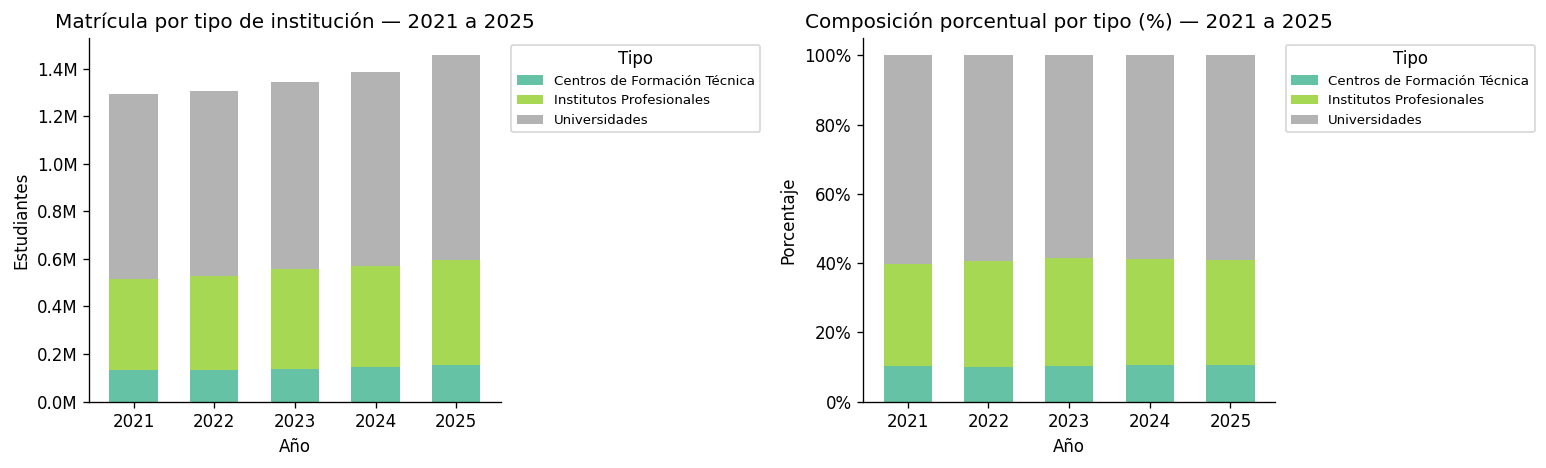

Distribución promedio 2021–2025 por tipo de institución:
tipo_institucion
Centros de Formación Técnica    10.3
Institutos Profesionales        30.5
Universidades                   59.2


In [ ]:
# 3.3.2 Evolución de la matrícula por tipo de institución
# Consideramos esta visualización la más importante del EDA porque muestra tanto el crecimiento total como la composición por tipo, que es nuestro target.

evol_tipo = (df.groupby([per_col, tipo_col])
               .size().unstack(fill_value=0))
evol_tipo_pct = evol_tipo.div(evol_tipo.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Absolutos
evol_tipo.plot(kind='bar', ax=axes[0], stacked=True,
               colormap='Set2', rot=0, width=0.6)
axes[0].set_title('Matrícula por tipo de institución — 2021 a 2025')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Estudiantes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].legend(title='Tipo', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

# Proporciones
evol_tipo_pct.plot(kind='bar', ax=axes[1], stacked=True,
                   colormap='Set2', rot=0, width=0.6)
axes[1].set_title('Composición porcentual por tipo (%) — 2021 a 2025')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Porcentaje')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(title='Tipo', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

print('Distribución promedio 2021–2025 por tipo de institución:')
print((evol_tipo.mean() / evol_tipo.mean().sum() * 100).round(1).to_string())


**Insight de negocio — Evolución de la matrícula:**

La composición por tipo de institución revela un sistema **estructuralmente tripartito** donde las universidades concentran la mayor proporción de matrícula, seguidas por IPs y CFTs. Este hallazgo tiene implicancias directas:

- Si la proporción se mantiene estable año a año, sugiere **equilibrio estructural** y las intervenciones deben ser cualitativas (mejorar la oferta existente).
- Si hay crecimiento diferencial (ej. IPs crecen más rápido), indica **demanda no satisfecha** por formación técnico-profesional que el diseño de becas debería reflejar.

Este patrón valida nuestra elección de `tipo_institucion` como variable target: la pertenencia a cada tipo refleja decisiones estructurales del estudiante.


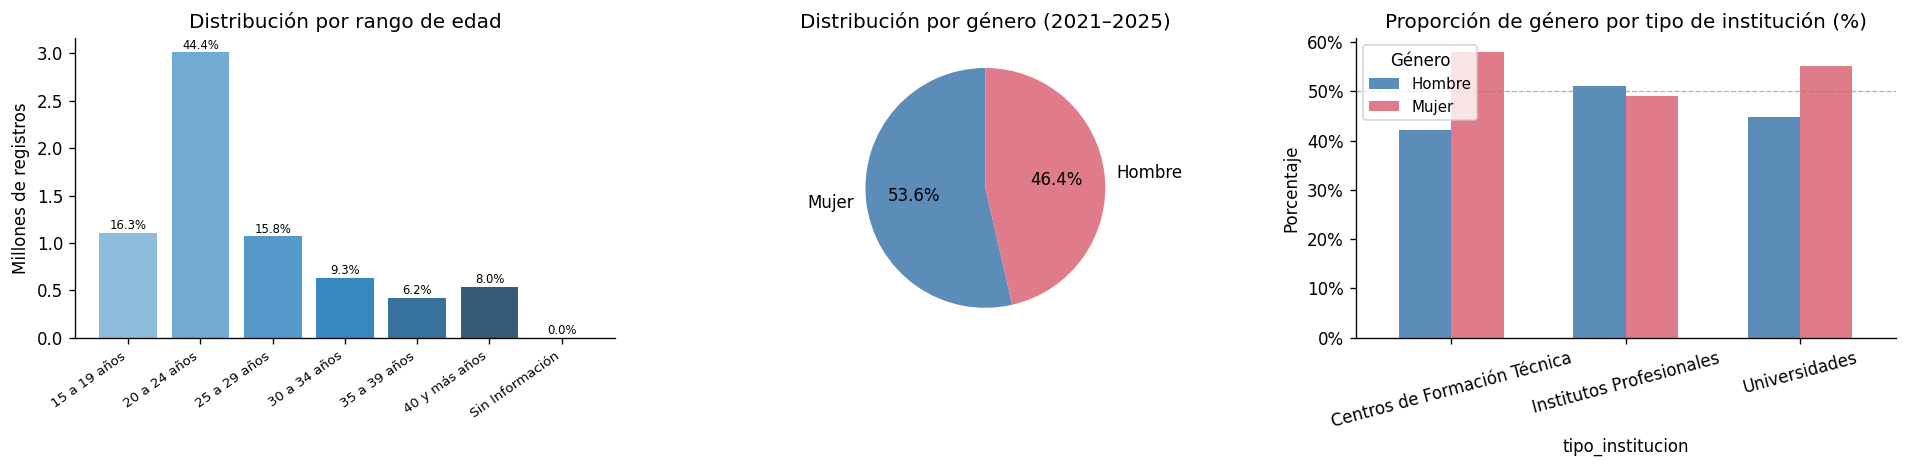

In [ ]:
# 3.3.3 Perfil demográfico edad y género
ORDEN_EDAD = [
    '15 a 19 años',
    '20 a 24 años',
    '25 a 29 años',
    '30 a 34 años',
    '35 a 39 años',
    '40 y más años',
    'Sin Información'
]
edad_col = 'rango_edad' if 'rango_edad' in df.columns else None
gen_col  = 'genero'     if 'genero'     in df.columns else 'gen_alu'

GEN_MAP = {1:'Hombre', 2:'Mujer'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Edad general
if edad_col:
    ed = df[edad_col].value_counts()
    orden_ok = [e for e in ORDEN_EDAD if e in ed.index]
    ed = ed.reindex(orden_ok)
    bars = axes[0].bar(range(len(ed)), ed.values/1e6,
                       color=sns.color_palette('Blues_d', len(ed)))
    axes[0].set_xticks(range(len(ed)))
    axes[0].set_xticklabels(ed.index, rotation=35, ha='right', fontsize=8)
    axes[0].set_title('Distribución por rango de edad')
    axes[0].set_ylabel('Millones de registros')
    for bar, v in zip(bars, ed.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{v/ed.sum()*100:.1f}%', ha='center', va='bottom', fontsize=7)

# Género general
gen_dist = df[gen_col].map(GEN_MAP).value_counts()
axes[1].pie(gen_dist.values, labels=gen_dist.index,
            colors=['#5B8DB8','#E07B8A'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':10})
axes[1].set_title('Distribución por género (2021–2025)')

# Género por tipo de institución
if edad_col:
    gen_tipo = (df.assign(gen_label=df[gen_col].map(GEN_MAP))
                  .groupby([tipo_col,'gen_label']).size().unstack(fill_value=0))
    gen_tipo_pct = gen_tipo.div(gen_tipo.sum(axis=1), axis=0)*100
    gen_tipo_pct.plot(kind='bar', ax=axes[2], color=['#5B8DB8','#E07B8A'],
                     rot=15, width=0.6)
    axes[2].set_title('Proporción de género por tipo de institución (%)')
    axes[2].set_ylabel('Porcentaje')
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[2].axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[2].legend(title='Género', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()


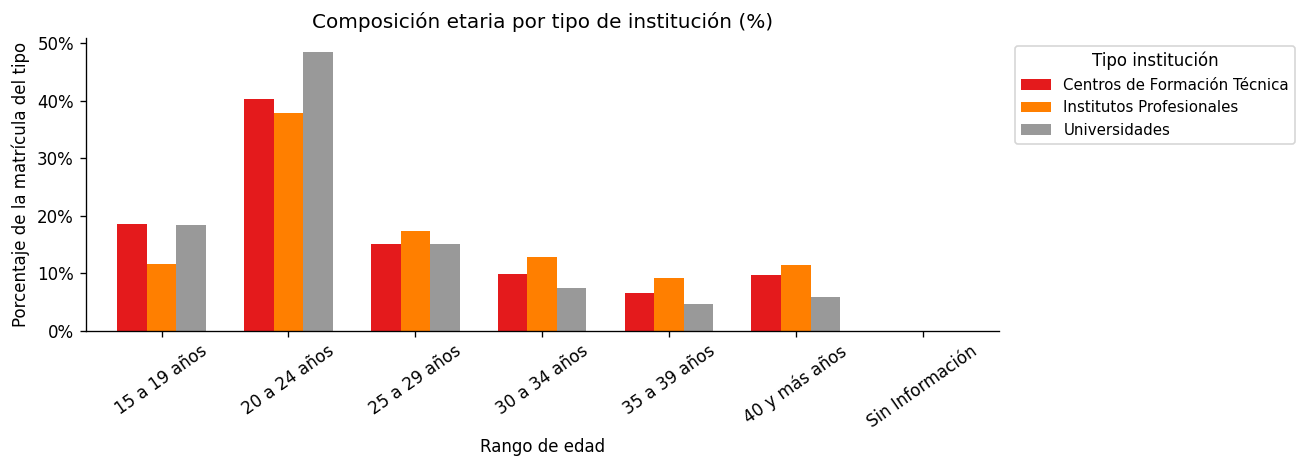

Porcentaje de estudiantes 30+ por tipo de institución:
tipo_institucion
Centros de Formación Técnica     9.6
Institutos Profesionales        11.4
Universidades                    5.9

Los CFTs e IPs concentran proporcionalmente más adultos que las
universidades, confirmando que son instituciones con perfiles etarios distintos.


In [ ]:
# 3.3.4 Edad por tipo de institución
# Este gráfico es central para nuestro proyecto si los perfiles etarios difieren sistemáticamente entre tipos de institución, el modelo supervisado
# tendrá buena base predictiva desde esta sola variable.

if edad_col:
    edad_tipo = (df.groupby([tipo_col, edad_col])
                   .size().unstack(fill_value=0)
                   .reindex(columns=orden_ok, fill_value=0))
    edad_tipo_pct = edad_tipo.div(edad_tipo.sum(axis=1), axis=0)*100

    fig, ax = plt.subplots(figsize=(11, 4))
    edad_tipo_pct.T.plot(kind='bar', ax=ax, rot=35,
                          colormap='Set1', width=0.7)
    ax.set_title('Composición etaria por tipo de institución (%)')
    ax.set_xlabel('Rango de edad')
    ax.set_ylabel('Porcentaje de la matrícula del tipo')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(title='Tipo institución', bbox_to_anchor=(1.01,1),
              loc='upper left', fontsize=9)
    sns.despine()
    plt.tight_layout()
    plt.show()

    # Cuantificar diferencia de adultos por tipo
    cols_adulto = [e for e in ['Entre 30 y 34 años','Entre 35 y 39 años',
                                '40 y más años'] if e in edad_tipo.columns]
    print('Porcentaje de estudiantes 30+ por tipo de institución:')
    pct_adulto = (edad_tipo[cols_adulto].sum(axis=1) /
                  edad_tipo.sum(axis=1) * 100).round(1)
    print(pct_adulto.to_string())
    print()
    print('Los CFTs e IPs concentran proporcionalmente más adultos que las')
    print('universidades, confirmando que son instituciones con perfiles etarios distintos.')


**Insight de negocio — Perfiles etarios diferenciados:**

La distribución de edad por tipo de institución confirma nuestra hipótesis central: **los perfiles demográficos son estructuralmente distintos**. Los CFTs e IPs presentan una proporción significativamente mayor de estudiantes en rangos 30+ comparado con universidades.

**Implicancia accionable:** Los programas de apoyo estudiantil diseñados con el "estudiante tipo" universitario (18-24 años, dedicación exclusiva) son inadecuados para el adulto trabajador de IP/CFT. Este insight justifica estrategias de retención diferenciadas por tipo de institución y segmento etario.


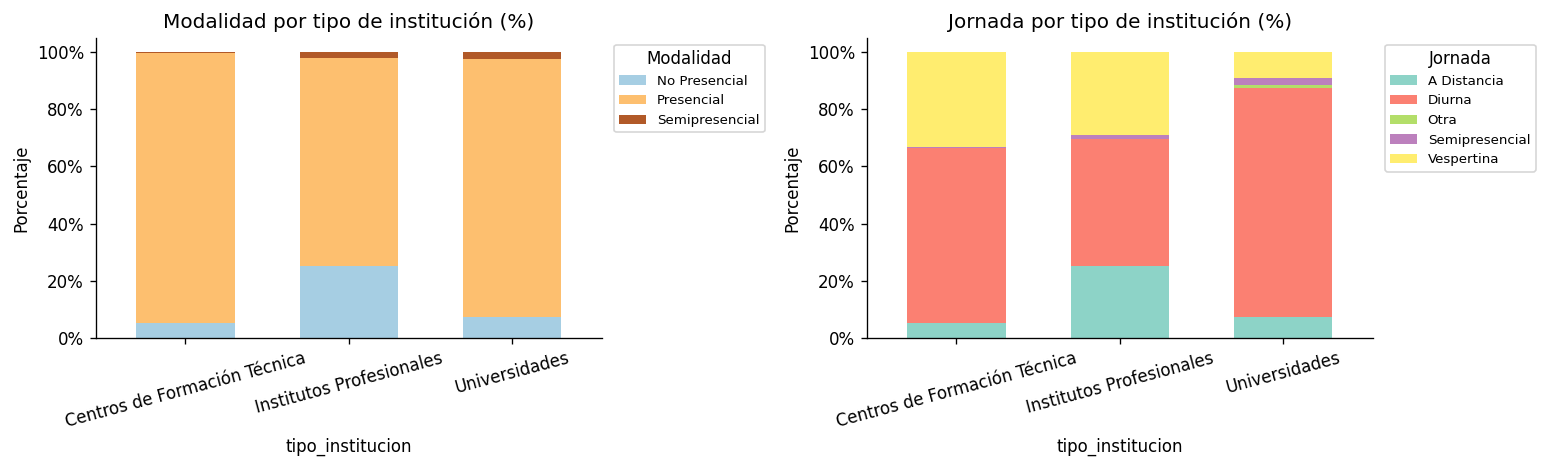

Los IPs muestran mayor pcantidad de modalidad no presencial y proporción de jornada vespertina que las universidades
reflejando el perfil de estudiante que es a su vez un trabajador que suelen tener estas instituciones.


In [ ]:
# 3.3.5 Modalidad y jornada por tipo de institución
mod_col = 'modalidad' if 'modalidad' in df.columns else None
jor_col = 'jornada'   if 'jornada'   in df.columns else None

if mod_col and jor_col:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Modalidad por tipo de institución
    mod_tipo = (df.groupby([tipo_col, mod_col])
                  .size().unstack(fill_value=0))
    mod_tipo_pct = mod_tipo.div(mod_tipo.sum(axis=1), axis=0)*100
    mod_tipo_pct.plot(kind='bar', ax=axes[0], stacked=True,
                      colormap='Paired', rot=15, width=0.6)
    axes[0].set_title('Modalidad por tipo de institución (%)')
    axes[0].set_ylabel('Porcentaje')
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[0].legend(title='Modalidad', bbox_to_anchor=(1.01,1),
                   loc='upper left', fontsize=8)

    # Jornada por tipo de institución
    jor_tipo = (df.groupby([tipo_col, jor_col])
                  .size().unstack(fill_value=0))
    jor_tipo_pct = jor_tipo.div(jor_tipo.sum(axis=1), axis=0)*100
    jor_tipo_pct.plot(kind='bar', ax=axes[1], stacked=True,
                      colormap='Set3', rot=15, width=0.6)
    axes[1].set_title('Jornada por tipo de institución (%)')
    axes[1].set_ylabel('Porcentaje')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].legend(title='Jornada', bbox_to_anchor=(1.01,1),
                   loc='upper left', fontsize=8)

    sns.despine()
    plt.tight_layout()
    plt.show()

    print('Los IPs muestran mayor pcantidad de modalidad no presencial y proporción de jornada vespertina que las universidades')
    print('reflejando el perfil de estudiante que es a su vez un trabajador que suelen tener estas instituciones.')


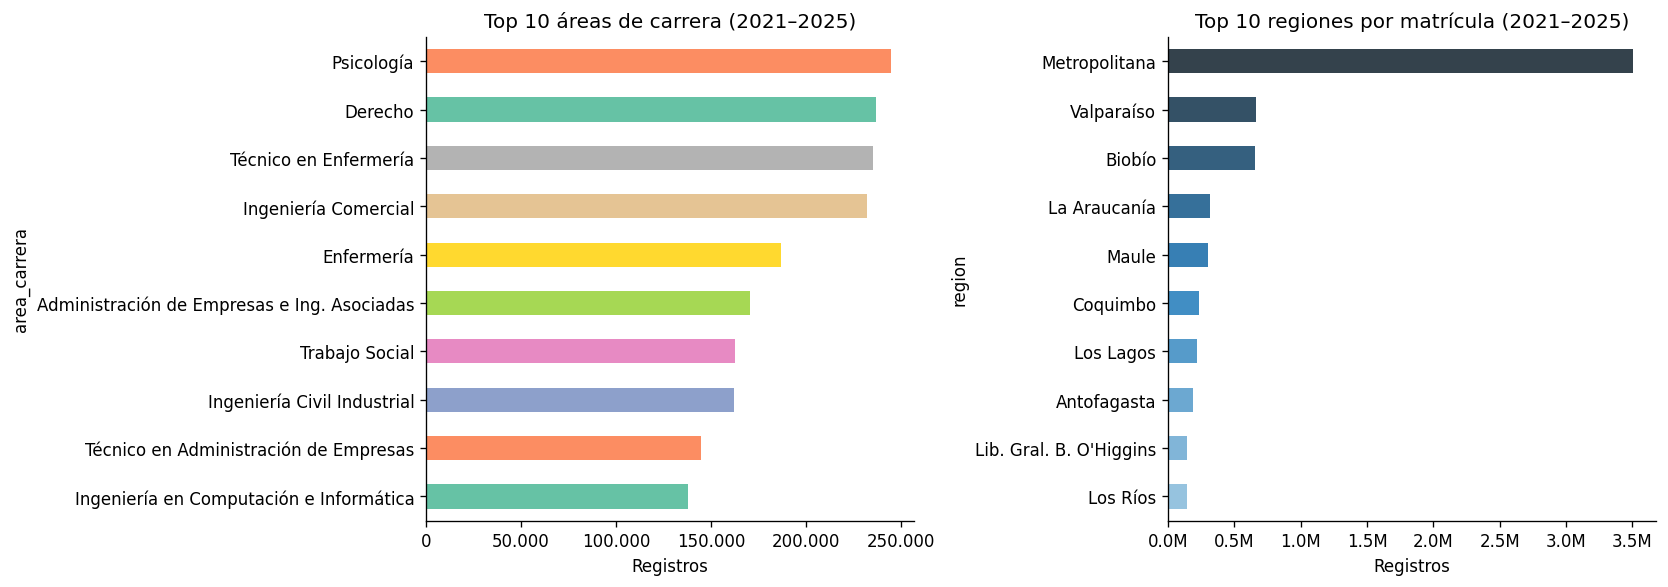

Región Metropolitana 51.6% del total de matrícula.
La concentración geográfica será un eje diferenciador fuerte en el clustering.


In [ ]:
# 3.3.6 Área de carrera y distribución geográfica
area_col = 'area_carrera' if 'area_carrera' in df.columns else None
reg_col  = 'region'       if 'region'       in df.columns else 'region_sede'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 áreas de carrera
if area_col:
    area_top = df[area_col].value_counts().head(10).sort_values()
    area_top.plot(kind='barh', ax=axes[0],
                  color=sns.color_palette(PALETTE, len(area_top)))
    axes[0].set_title('Top 10 áreas de carrera (2021–2025)')
    axes[0].set_xlabel('Registros')

    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x):,}'.replace(',', '.')))


# Concentración regional
if reg_col in df.columns:
    reg_top = df[reg_col].value_counts().head(10).sort_values()
    reg_top.plot(kind='barh', ax=axes[1],
                  color=sns.color_palette('Blues_d', len(reg_top)))
    axes[1].set_title('Top 10 regiones por matrícula (2021–2025)')
    axes[1].set_xlabel('Registros')
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

sns.despine()
plt.tight_layout()
plt.show()

if reg_col in df.columns:
    rm = df[reg_col].str.contains('Metropolitana', na=False).sum()
    print(f'Región Metropolitana {rm/len(df)*100:.1f}% del total de matrícula.')
    print('La concentración geográfica será un eje diferenciador fuerte en el clustering.')


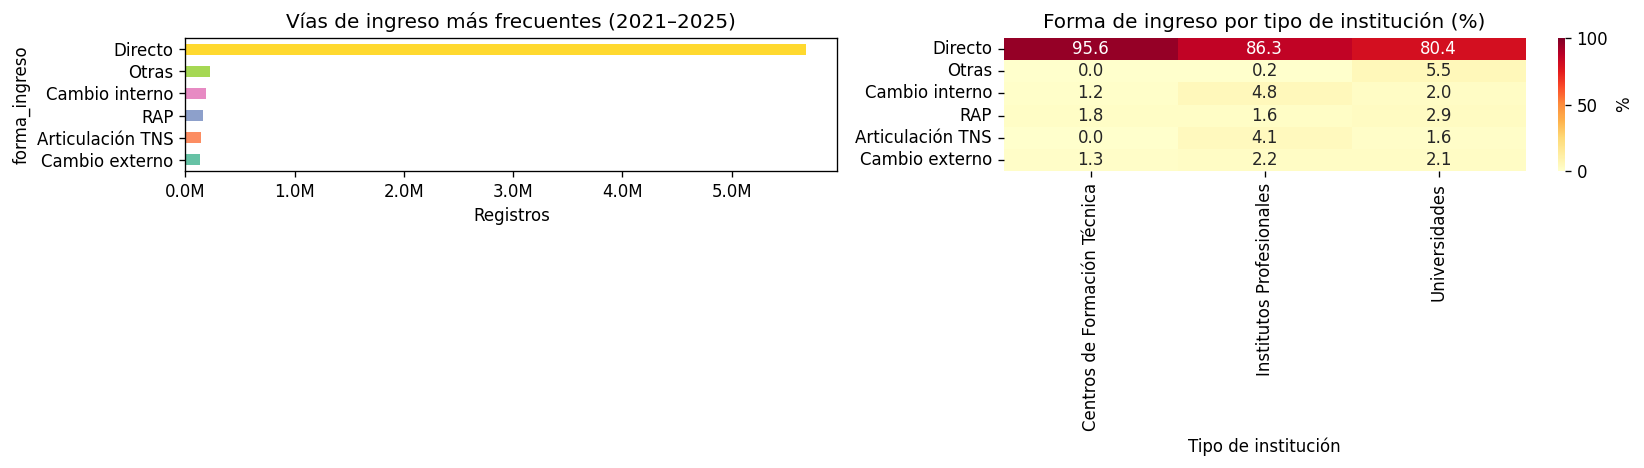

Los 3 tipos de instituciones superan el ingreso directo superan el 80%.
Por esto seguramente se eliminara del modelado.


In [ ]:
# 3.3.7 Forma de ingreso por tipo de institución

fi_col = 'forma_ingreso'

FI_MAP = {1:'Directo', 2:'Continuidad', 3:'Cambio interno',
          4:'Cambio externo', 5:'RAP', 6:'Extranjero',
          7:'PACE', 8:'Inclusión', 9:'Esp. especiales',
          10:'Otras', 11:'Articulación TNS'}

if fi_col in df.columns:
    fi_label = df[fi_col].map(FI_MAP)

    fi_label = fi_label.fillna('Otras')

    top_fi = fi_label.value_counts().head(6).index
    fi_label_top = fi_label.where(fi_label.isin(top_fi), 'Otros')

    fi_tipo = pd.crosstab(df[tipo_col], fi_label_top, normalize='index') * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Distribución general
    fi_label.value_counts().loc[top_fi].sort_values().plot(
        kind='barh', ax=axes[0],
        color=sns.color_palette('Set2', len(top_fi)))
    axes[0].set_title('Vías de ingreso más frecuentes (2021–2025)')
    axes[0].set_xlabel('Registros')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

    # Heatmap por tipo
    sns.heatmap(fi_tipo[top_fi].T, ax=axes[1],
                cmap='YlOrRd',
                annot=True,
                fmt='.1f',
                vmin=0, vmax=100,
                cbar_kws={'label':'%'})

    axes[1].set_title('Forma de ingreso por tipo de institución (%)')
    axes[1].set_xlabel('Tipo de institución')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    print('Los 3 tipos de instituciones superan el ingreso directo superan el 80%.')
    print('Por esto seguramente se eliminara del modelado.')

**Insight de negocio — Forma de ingreso como diferenciador:**

Las formas de ingreso varían marcadamente entre tipos de institución. Las universidades concentran el ingreso vía sistema centralizado (PSU/PAES), mientras que IPs y CFTs dependen más del ingreso directo y mecanismos alternativos.

**Valor para orientación vocacional:** Un orientador que conoce la forma de ingreso más probable del estudiante puede anticipar en qué tipo de institución terminará, y ofrecer orientación preventiva si el perfil sugiere una mejor alternativa.


### 3.4 Diagnóstico de Calidad de los Datos

Realizamos un análisis sistemático de la calidad del dataset, identificando valores nulos,valores especiales codificados por el SIES que funcionan como nulos encubiertos, y outliers en variables numéricas. Los hallazgos de esta sección fundamentarán directamente la estrategia de limpieza que aplicaremos en la Preparación de Datos.


In [ ]:
# 3.4.1 Mapa de valores nulos
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
calidad   = pd.DataFrame({'Nulos': nulos,
                           '% Nulos': nulos_pct,
                           'Tipo': df.dtypes}).sort_values('% Nulos', ascending=False)

print(f'Total registros       : {len(df):>12,}')
print(f'Total columnas        : {df.shape[1]:>12}')
print(f'Columnas con nulos    : {(nulos > 0).sum():>12} de {df.shape[1]}')
print()
display(calidad[calidad['Nulos'] > 0]
        .style.background_gradient(subset=['% Nulos'], cmap='Reds'))


Total registros       :    6,781,991
Total columnas        :           52
Columnas con nulos    :            6 de 52



,Nulos,% Nulos,Tipo
codigo_demre,1724646,25.430000,Int64
anios_acred_inst,243969,3.600000,Int64
costo_titulo,3516,0.050000,float64
valor_matricula,3668,0.050000,Int64
valor_arancel,2874,0.040000,Int64
costo_titulacion,2825,0.040000,float64


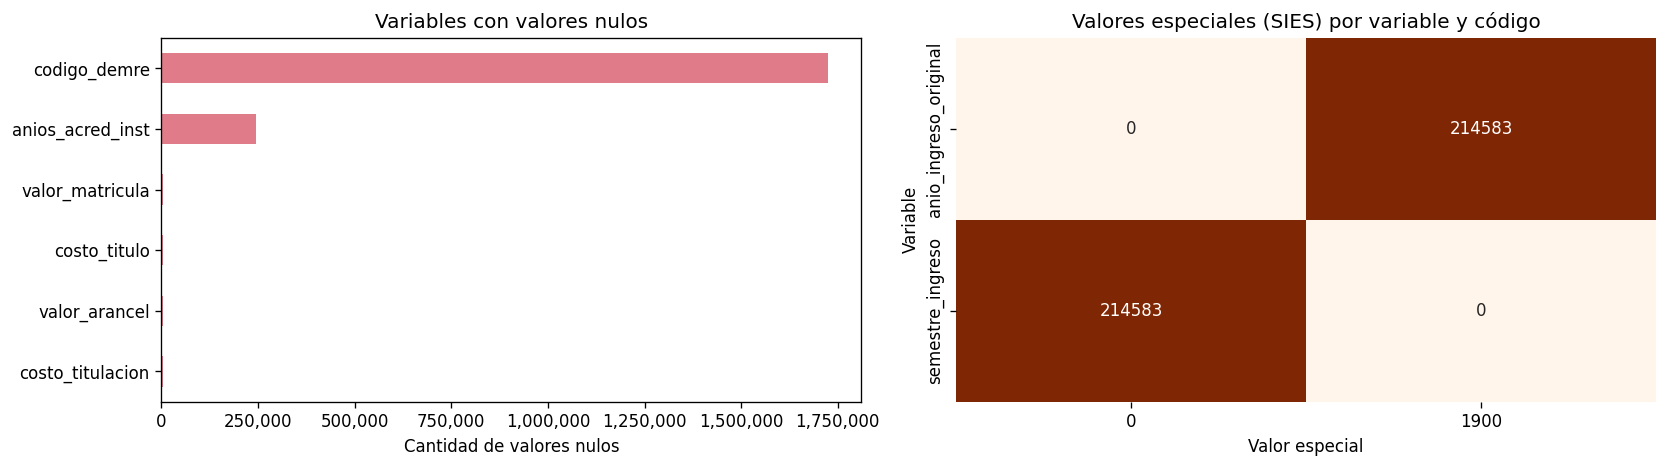

In [ ]:
# 3.4.2 Visualización de nulos y valores especiales del SIES
# El esquema SIES utiliza códigos numéricos para 'sin información':
# 9995 / 9998 / 9999 / 1900 en columnas de año → equivalen a nulos.
# Los identificamos antes de cualquier transformación.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Nulos por variable
nulos_vis = nulos[nulos > 0].sort_values(ascending=True)
if len(nulos_vis):
    nulos_vis.plot(kind='barh', ax=axes[0], color='#E07B8A')
    axes[0].set_xlabel('Cantidad de valores nulos')
    axes[0].set_title('Variables con valores nulos')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
else:
    axes[0].text(0.5, 0.5, 'Sin nulos explícitos detectados',
                 ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Variables con valores nulos')

# Valores especiales en columnas numéricas de año
VALS_ESP = [9995, 9998, 9999, 1900, 0]
cols_año  = [c for c in df.columns
             if any(k in c.lower() for k in ['anio','ingreso','duracion','periodo'])]
esp_rows  = []
for col in cols_año:
    if df[col].dtype in ['int64','float64','Int64']:
        for v in VALS_ESP:
            n = (df[col] == v).sum()
            if n > 0:
                esp_rows.append({'Variable': col, 'Valor especial': v, 'N°': n})

if esp_rows:
    df_esp = pd.DataFrame(esp_rows)
    df_esp_pivot = df_esp.pivot_table(index='Variable',
                                      columns='Valor especial',
                                      values='N°', fill_value=0)

    sns.heatmap(df_esp_pivot, ax=axes[1], cmap='Oranges',
                annot=True, fmt='.0f', cbar=False)

    axes[1].set_title('Valores especiales (SIES) por variable y código')
else:
    axes[1].text(0.5, 0.5, 'Sin valores especiales detectados',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Valores especiales (SIES)')

plt.tight_layout()
plt.show()


#### Justificación metodológica — Elección del criterio IQR

Para la detección de outliers en variables numéricas se aplica el **criterio IQR**
(Rango Intercuartílico) en lugar del método Z-score. La elección se fundamenta en las
características estadísticas del dataset:

| Método | Supuesto | Aplicable cuando |
|---|---|---|
| **Z-score** | Distribución normal (simétrica) | Variables con skewness ≈ 0 |
| **IQR (1.5×)** | Sin supuesto distribucional | Variables asimétricas (skewed) |
| **IQR (3×)** | Sin supuesto distribucional | Outliers extremos en variables con colas muy largas |

Las variables de **costo** (`valor_arancel`, `valor_matricula`) presentan distribuciones
típicamente **asimétricas positivas** (right-skewed) en datos socioeconómicos: la mayoría
de los valores se concentran en rangos bajos-medios con una cola derecha extensa hacia
valores muy altos. En este escenario, el Z-score sobreestima los límites normales y
subestima el número real de outliers. El IQR es **robusto a la asimetría** y no asume
ninguna distribución subyacente.

La celda siguiente calcula la **asimetría (skewness)** de cada variable numérica para
confirmar empíricamente este supuesto.


── Análisis de asimetría por variable numérica ──
  Variables asimétricas (|skew| > 1): 14 de 21
  → IQR es el método correcto para la mayoría de las variables numéricas.



,Variable,Skewness,Distribución
14,valor_matricula,93.76,Asimétrica positiva (usar IQR)
15,valor_arancel,10.28,Asimétrica positiva (usar IQR)
6,sem_ing_carr_act,4.52,Asimétrica positiva (usar IQR)
7,cod_inst,3.47,Asimétrica positiva (usar IQR)
10,version,3.32,Asimétrica positiva (usar IQR)
20,forma_ingreso,2.85,Asimétrica positiva (usar IQR)
19,costo_titulo,2.46,Asimétrica positiva (usar IQR)
18,costo_titulacion,2.38,Asimétrica positiva (usar IQR)
9,cod_carrera,2.21,Asimétrica positiva (usar IQR)
8,cod_sede,1.98,Asimétrica positiva (usar IQR)


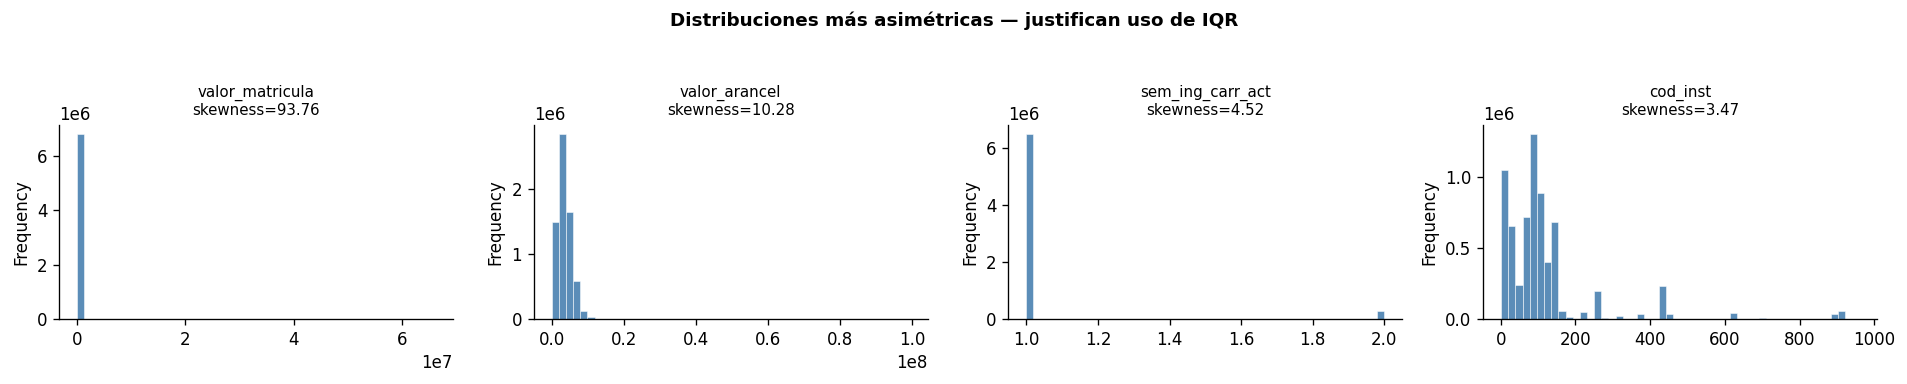

In [ ]:
# 3.4.2b Análisis de asimetría (skewness) para justificar el criterio IQR
# Skewness > 1 o < -1 indica distribución marcadamente asimétrica,
# lo que invalida el uso de Z-score (que asume normalidad).

excluir_skew = ['cat_periodo', 'genero', 'gen_alu']
num_cols_skew = [c for c in df.select_dtypes('number').columns if c not in excluir_skew]

skew_df = pd.DataFrame({
    'Variable': num_cols_skew,
    'Skewness': [df[c].dropna().skew() for c in num_cols_skew]
}).sort_values('Skewness', ascending=False)

skew_df['Distribución'] = skew_df['Skewness'].apply(
    lambda s: 'Asimétrica positiva (usar IQR)' if s >  1 else
              ('Asimétrica negativa (usar IQR)' if s < -1 else
               'Aproximadamente normal (Z-score viable)')
)

print('── Análisis de asimetría por variable numérica ──')
print(f'  Variables asimétricas (|skew| > 1): '
      f"{(skew_df['Skewness'].abs() > 1).sum()} de {len(skew_df)}")
print(f'  → IQR es el método correcto para la mayoría de las variables numéricas.')
print()
display(skew_df.style
        .background_gradient(subset=['Skewness'], cmap='RdYlGn_r')
        .format({'Skewness': '{:.2f}'})
)

# Histograma de las 4 variables más asimétricas
top4_skew = skew_df.head(4)['Variable'].tolist()
if top4_skew:
    fig, axes = plt.subplots(1, len(top4_skew), figsize=(4*len(top4_skew), 3))
    if len(top4_skew) == 1: axes = [axes]
    for ax, col in zip(axes, top4_skew):
        df[col].dropna().plot(kind='hist', bins=50, ax=ax,
                               color='#5B8DB8', edgecolor='white', linewidth=0.3)
        sk = df[col].dropna().skew()
        ax.set_title(f'{col}\nskewness={sk:.2f}', fontsize=9)
        ax.set_xlabel('')
    plt.suptitle('Distribuciones más asimétricas — justifican uso de IQR',
                 fontsize=11, fontweight='bold', y=1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()


In [ ]:
# 3.4.3 Outliers en variables numéricas (criterio IQR)
excluir = ['cat_periodo','genero','gen_alu']
num_cols = [c for c in df.select_dtypes('number').columns if c not in excluir]

resumen_out = []
for col in num_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < li) | (s > ls)).sum()
    resumen_out.append({
        'Variable': col, 'Q1': round(Q1,1), 'Q3': round(Q3,1),
        'Lím. inf': round(li,1), 'Lím. sup': round(ls,1),
        'N° outliers': n_out, '% outliers': round(n_out/len(s)*100,2)
    })

df_out = (pd.DataFrame(resumen_out)
            .sort_values('% outliers', ascending=False))
print('── Outliers detectados por variable numérica ──')
display(df_out[df_out['N° outliers'] > 0]
        .style.background_gradient(subset=['% outliers'], cmap='YlOrRd'))


── Outliers detectados por variable numérica ──


,Variable,Q1,Q3,Lím. inf,Lím. sup,N° outliers,% outliers
0,id,436647.000000,1351018.500000,-934910.200000,2722575.800000,1400967,20.660000
10,version,1.000000,1.000000,1.000000,1.000000,1252666,18.470000
20,forma_ingreso,1.000000,1.000000,1.000000,1.000000,1099518,16.210000
8,cod_sede,1.000000,9.000000,-11.000000,21.000000,747814,11.030000
7,cod_inst,39.000000,117.000000,-78.000000,234.000000,690813,10.190000
19,costo_titulo,0.000000,58150.000000,-87225.000000,145375.000000,664575,9.800000
14,valor_matricula,132000.000000,255000.000000,-52500.000000,439500.000000,488818,7.210000
4,semestre_ingreso,1.000000,1.000000,1.000000,1.000000,448544,6.610000
2,fec_nac_alu,199401.000000,200209.000000,198189.000000,201421.000000,442711,6.530000
18,costo_titulacion,0.000000,191557.000000,-287335.500000,478892.500000,440465,6.500000


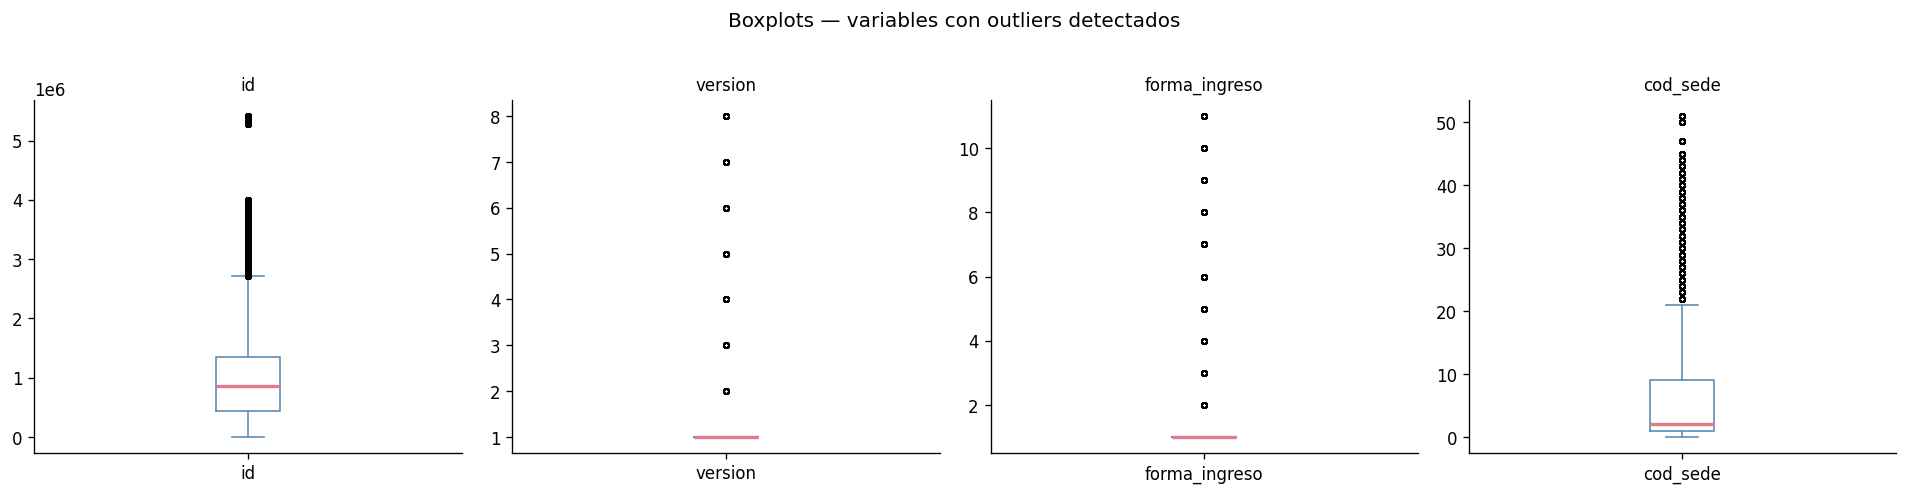

In [ ]:
# 3.4.4 Boxplots de variables con outliers significativos
vars_out = df_out[df_out['N° outliers'] > 0]['Variable'].tolist()[:4]

if vars_out:
    fig, axes = plt.subplots(1, len(vars_out),
                              figsize=(4*len(vars_out), 4))
    if len(vars_out) == 1: axes = [axes]
    for ax, col in zip(axes, vars_out):
        df[col].dropna().plot(
            kind='box', ax=ax,
            boxprops=dict(color='#5B8DB8'),
            medianprops=dict(color='#E07B8A', linewidth=2),
            whiskerprops=dict(color='#5B8DB8'),
            capprops=dict(color='#5B8DB8'),
            flierprops=dict(marker='o', color='#E07B8A',
                            alpha=0.3, markersize=3)
        )
        ax.set_title(col, fontsize=10)
    plt.suptitle('Boxplots — variables con outliers detectados', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()


In [ ]:
# 3.4.5 Resumen final de calidad y plan de acción

print('  RESUMEN DE CALIDAD')
print()
print(f'  Total registros             : {len(df):>12,}')
print(f'  Total columnas              : {df.shape[1]:>12}')
print(f'  Cols con nulos explícitos   : {(df.isnull().sum()>0).sum():>12} de {df.shape[1]}')
print(f'  Variables numéricas         : {len(df.select_dtypes("number").columns):>12}')
print(f'  Variables categóricas       : {len(df.select_dtypes("object").columns):>12}')
print()
print('  ACCIONES PARA LA PREPARACIÓN DE DATOS (Sección 4):')
print('  1. ELIMINAR columna codigo_demre (1.75M nulos, 25% — irrecuperable)')
print('  2. Reemplazar valor código 1900 en anio_ingreso_original y semestre_ingreso por NaN (214.583 registros cada uno)')
print('  3. Excluir del análisis numérico las columnas id, version y cod_sede ya que son son identificadores no variables continuas')
print('  4. Imputar nulos por moda (categóricas) o mediana (numéricas)')
print('  5. Aplicar capping (percentil 99) a outliers en costos')
print('  6. Codificar variables ordinales (rango_edad) con OrdinalEncoder')
print('  7. Codificar variables nominales con OneHotEncoding (baja cardinalidad) o TargetEncoding (región, área_carrera) para evitar explosión dimensional')
print('  8. Escalar variables numéricas con StandardScaler')
print('  9. Evaluar PCA para reducir dimensionalidad: descartado porque MiniBatchKMeans')
print('     con StandardScaler converge en dimensiones originales y la interpretabilidad')
print('     de variables es prioritaria para los insights de negocio.')



  RESUMEN DE CALIDAD

  Total registros             :    6,781,991
  Total columnas              :           52


  Cols con nulos explícitos   :            6 de 52
  Variables numéricas         :           23
  Variables categóricas       :            0

  ACCIONES PARA LA PREPARACIÓN DE DATOS (Sección 4):
  1. ELIMINAR columna codigo_demre (1.75M nulos, 25% — irrecuperable)
  2. Reemplazar valor código 1900 en anio_ingreso_original y semestre_ingreso por NaN (214.583 registros cada uno)
  3. Excluir del análisis numérico las columnas id, version y cod_sede ya que son son identificadores no variables continuas
  4. Imputar nulos por moda (categóricas) o mediana (numéricas)
  5. Aplicar capping (percentil 99) a outliers en costos
  6. Codificar variables ordinales (rango_edad) con OrdinalEncoder
  7. Codificar variables nominales con OneHotEncoding (baja cardinalidad) o TargetEncoding (región, área_carrera) para evitar explosión dimensional
  8. Escalar variables numéricas con StandardScaler
  9. Evaluar PCA para reducir dimensionalidad: descartado porque MiniBatchKMeans
     con StandardScaler co

**Insight de negocio — Diagnóstico de calidad y sus implicancias:**

El análisis de calidad revela que los datos del SIES tienen una estructura de nulos **no aleatoria**: los códigos especiales (9995, 9998, 9999) se concentran en variables de trayectoria (`anio_ingreso_original`), lo que indica que la "falta de información" es en sí misma informativa — son estudiantes cuyo historial de transferencia no fue registrado.

**Decisión crítica:** No eliminar registros con estos códigos sino extraer la señal (transferencia sí/no) antes de nullificar. Eliminar registros con códigos especiales sesgaría la muestra hacia estudiantes recientes y universidades, distorsionando los perfiles de IP/CFT. Los outliers en costos corresponden a programas reales (postgrado, medicina) — el capping al P99 preserva la información sin distorsionar K-Means.


**Validación metodológica:** El análisis de asimetría confirmó que las variables de costo presentan skewness > 1 (distribución right-skewed), lo que valida el uso de IQR sobre Z-score. El capping al percentil 99 —en lugar de eliminación— preserva la integridad del dataset (6.7 M registros) y evita el sesgo que introduciría eliminar registros de programas costosos legítimos como Medicina o Postgrado.

## 4. Preparación de los Datos

Las decisiones de limpieza, ingeniería de características y transformación se fundamentan directamente en los hallazgos del diagnóstico de calidad de la sección 3.4.

Trabajamos sobre una copia limpia del DataFrame original `df_modificada` para preservar `df` intacto y poder comparar en cualquier momento.


### 4.1 Limpieza
| Problema | Variables | Estrategia |
|---|---|---|
| Nulos irrecuperables (>25%) | `codigo_demre` | Eliminar |
| Identificadores sin valor predictivo | `id`, `mrun`, `codigo_unico`, `fec_nac_alu`, `cod_sede`, `version`, `cod_inst`, `cod_carrera` | Eliminar |
| Baja discriminación entre tipos | `forma_ingreso`, `modalidad` | Eliminar |
| Redundantes con target o con otras variables | `tipo_institucion_2`, `tipo_institucion_3`, `area_cine`, `subarea_cine`, `cine_f_97_area`, `cine_f_97_subarea`, `area_conocimiento` | Eliminar |
| Alta cardinalidad | `nombre_institucion`, `nombre_carrera`, `nomb_sede`, `provincia_sede`, `comuna_sede`, `acre_inst_desde_hasta`, `costo_tit_explicacion_observacion` | Eliminar |
| Códigos SIES en columnas de año | `anio_ingreso_original`: 9995=sin info; **9998/9999/1900=transferencia** | Extraer señal, luego reemplazar por NaN |
| Variables de costo en tipo string | `valor_matricula`, `valor_arancel` | Convertir a numérico |
| Nulos imputables | `anios_acred_inst`, costos | Mediana agrupada por `tipo_institucion` |
| Outliers en costos | `valor_arancel`, `valor_matricula`, `costo_titulacion`, `costo_titulo` | Capping P99 |


In [ ]:
# 4.1.1 Copia de trabajo y eliminacion de columnas
# Optimizacion de memoria: en lugar de df.copy() (que duplicaria ~5 GB), creamos
# df_modificada como el resultado de drop(columns=...) y liberamos df.
import gc
COLS_DROP = [
    # Irrecuperable
    'codigo_demre',
    # Identificadores
    'id', 'mrun', 'codigo_unico', 'fec_nac_alu', 'cod_sede',
    'version', 'cod_inst', 'cod_carrera',
    # Baja discriminacion confirmada
    'forma_ingreso', 'modalidad',
    # Redundantes
    'tipo_institucion_2', 'tipo_institucion_3',
    'area_cine', 'subarea_cine', 'cine_f_97_area', 'cine_f_97_area_area',
    'cine_f_97_subarea', 'area_conocimiento',
    # Alta cardinalidad
    'nombre_institucion', 'nombre_carrera', 'nomb_sede',
    'provincia_sede', 'comuna_sede',
    'acre_inst_desde_hasta', 'costo_tit_explicacion_observacion',
    # Nivel detallado (cubierto por nivel_global)
    'nivel_carrera_1', 'nivel_carrera_2',
    # Duracion parcial (cubierta por duracion_carrera)
    'dur_estudio_carr', 'dur_proceso_tit',
    # Plan y requisito baja variabilidad
    'tipo_plan_carr', 'requisito_ingreso', 'vigencia_carrera',
    'sem_ing_carr_act',
]
cols_drop = [c for c in COLS_DROP if c in df.columns]
df_modificada = df.drop(columns=cols_drop)
del df
gc.collect()
print(f'Eliminadas: {len(cols_drop)} columnas | Restantes: {df_modificada.shape[1]}')


Eliminadas: 32 columnas | Restantes: 20


In [ ]:
# 4.1.2 Extraemos es_transferencia ANTES de nullificar códigos SIES
# Según el esquema oficial (ER_Matricula_SIES):
#   9995        -> sin información          -> tratar como NaN
#   9998        -> transferencia interna   ->  información real de trayectoria
#   9999 / 1900 -> transferencia externa   -> información real de trayectoria
# Extraemos esta señal ANTES de nullificar para no perder información que pueda ser util para los perfiles

CODIGOS_TRANSFERENCIA = [9998, 9999, 1900]
CODIGOS_NULL          = [9995]

if 'anio_ingreso_original' in df_modificada.columns:
    df_modificada['es_transferencia'] = (
        df_modificada['anio_ingreso_original']
        .isin(CODIGOS_TRANSFERENCIA).astype(int)
    )
    n = df_modificada['es_transferencia'].sum()
    print(f'Transferencias detectadas: {n:,} ({n/len(df_modificada)*100:.1f}%)')

# Ahora sí reemplazamos todos los códigos por NaN
cols_año = [c for c in df_modificada.columns
            if any(k in c.lower() for k in ['anio', 'semestre'])]
for col in cols_año:
    if df_modificada[col].dtype in ['int64', 'float64', 'Int64']:
        df_modificada[col] = df_modificada[col].replace(CODIGOS_NULL, pd.NA)
print('Códigos SIES reemplazados por NaN en columnas de año.')

Transferencias detectadas: 214,583 (3.2%)


Códigos SIES reemplazados por NaN en columnas de año.


In [ ]:
# 4.1.3 Convertir costos y aranceles de string a numérico
# valor_matricula y valor_arancel son tipo Cadena en el esquema SIES.

COLS_STR_TO_NUM = ['valor_matricula', 'valor_arancel']
for col in COLS_STR_TO_NUM:
    if col in df_modificada.columns and not pd.api.types.is_numeric_dtype(df_modificada[col]):
        df_modificada[col] = pd.to_numeric(
            df_modificada[col].astype(str)
                        .str.replace(',', '.', regex=False)
                        .str.replace(' ', '', regex=False),
            errors='coerce'
        )
        print(f'{col}: convertida a numérico | nulos post-conversión: {df_modificada[col].isna().sum():,}')

In [ ]:
# 4.1.4 Imputación de nulos
# Numéricas: mediana agrupada por tipo_institucion (más precisa que mediana global ya que costos y antigüedades difieren estructuralmente entre tipos).
# Categóricas: moda global.

NUM_IMPUTAR = [
    'anios_acred_inst', 'anio_ingreso_actual', 'anio_ingreso_original',
    'semestre_ingreso', 'valor_arancel', 'valor_matricula',
    'costo_titulacion', 'costo_titulo', 'duracion_carrera'
]
NUM_IMPUTAR = [c for c in NUM_IMPUTAR if c in df_modificada.columns]

for col in NUM_IMPUTAR:
    med_grupo  = df_modificada.groupby('tipo_institucion')[col].transform('median')
    med_global = df_modificada[col].median()
    df_modificada[col] = df_modificada[col].fillna(med_grupo).fillna(med_global)

for col in df_modificada.select_dtypes('object').columns:
    if df_modificada[col].isna().any():
        df_modificada[col] = df_modificada[col].fillna(df_modificada[col].mode()[0])

nulos_rest = df_modificada.isnull().sum().sum()
print(f'Nulos restantes tras imputación: {nulos_rest}')

Nulos restantes tras imputación: 0


In [ ]:
# 4.1.5 Capping de outliers al percentil 99
# Optamos por capping (no eliminación) porque los registros con costos extremos
# son válidos; solo limitamos su influencia en el modelo.

COLS_COSTO = ['valor_arancel', 'valor_matricula', 'costo_titulacion', 'costo_titulo']
COLS_COSTO = [c for c in COLS_COSTO if c in df_modificada.columns]

for col in COLS_COSTO:
    p99 = df_modificada[col].quantile(0.99)
    n   = (df_modificada[col] > p99).sum()
    df_modificada[col] = df_modificada[col].clip(upper=p99)
    print(f'{col:<25} P99={p99:>12,.0f} | capados={n:>6,}')

print(f'\nDimensiones tras limpieza: {df_modificada.shape}')


valor_arancel             P99=   9,632,904 | capados=67,132
valor_matricula           P99=     696,000 | capados=64,451


costo_titulacion          P99=     856,879 | capados=67,565


costo_titulo              P99=     310,000 | capados=59,448

Dimensiones tras limpieza: (6781991, 21)


In [ ]:
df_modificada.head(1)

,cat_periodo,genero,rango_edad,anio_ingreso_original,semestre_ingreso,anio_ingreso_actual,tipo_institucion,jornada,duracion_carrera,region,...,formato_valores,valor_matricula,valor_arancel,area_carrera,acred_carrera,acred_inst,anios_acred_inst,costo_titulacion,costo_titulo,es_transferencia
0,2021,2,35 a 39 años,2021,1,2021,Centros de Formación Técnica,Diurna,5,Metropolitana,...,,0,1845000,Técnico en Enfermería,NO ACREDITADA,ACREDITADA,6,120000.0,0.0,0


### 4.2 Ingeniería de Características

| Variable nueva | Fórmula | Justificación |
|---|---|---|
| `antiguedad` | `cat_periodo − anio_ingreso_actual` | Captura si el estudiante es de primer año o lleva varios años |
| `es_transferido` | `anio_ingreso_original {9998, 9999, 1900}` | Ya creada en 4.1.2. Distingue ingreso directo de transferencia |
| `es_mayor_de_30` | `rango_edad {30–34, 35–39, 40+}` | Concentra el segmento de adultos trabajadores el la seccion anterior descubrimos que el 9.6% en CFT y 11.4% en IP vs 5.9% en universidades |
| `es_regiones` | `region ≠ 'Metropolitana'` | La RM concentra 51.6% de la matrícula binaria simple con alto poder discriminador |
| `es_vespertino` | `jornada contiene 'Vespertino'` | La jornada diferencia más que la modalidad entre tipos |

**Variables a eliminar tras redundancia en la ingeniería:**
`anio_ingreso_original`, `anio_ingreso_actual`, `semestre_ingreso`, `cat_periodo`, `region`, `jornada`

In [ ]:
# 4.2.1 Crear variables derivadas
# Antigüedad en la carrera
if {'cat_periodo', 'anio_ingreso_actual'}.issubset(df_modificada.columns):
    df_modificada['antiguedad'] = (
        df_modificada['cat_periodo'] - df_modificada['anio_ingreso_actual']
    ).clip(lower=0)

# Estudiante mayor de 30
EDADES_MAYOR_30 = [
    'Entre 30 y 34 años', 'Entre 35 a 39 años', '40 y más años',
    '30 a 34 años', '35 a 39 años'
]

if 'rango_edad' in df_modificada.columns:
    df_modificada['es_mayor_de_30'] = (
        df_modificada['rango_edad']
        .astype(str)
        .str.strip()
        .isin(EDADES_MAYOR_30)
        .astype(int)
    )

# Fuera de Región Metropolitana
if 'region' in df_modificada.columns:
    df_modificada['es_regiones'] = (
        ~df_modificada['region']
        .astype(str)
        .str.contains('Metropolitana', case=False, na=False)
    ).astype(int)

# Jornada vespertina
if 'jornada' in df_modificada.columns:
    df_modificada['es_vespertino'] = (
        df_modificada['jornada']
        .astype(str)
        .str.lower()
        .str.contains('Vespertino', na=False)
    ).astype(int)

# Nota: es_transferido ya viene de 4.1.2 → renombramos si aún no está ajustado
if 'es_transferencia' in df_modificada.columns and 'es_transferido' not in df_modificada.columns:
    df_modificada['es_transferido'] = df_modificada['es_transferencia']

# Verificación
for v in ['antiguedad', 'es_transferido', 'es_mayor_de_30', 'es_regiones', 'es_vespertino']:
    if v in df_modificada.columns:
        print(f'{v:<20}: media={df_modificada[v].mean():.3f} | nulos={df_modificada[v].isna().sum()}')

antiguedad          : media=1.685 | nulos=0
es_transferido      : media=0.032 | nulos=0
es_mayor_de_30      : media=0.235 | nulos=0
es_regiones         : media=0.484 | nulos=0
es_vespertino       : media=0.000 | nulos=0


In [ ]:
# 4.2.2 Eliminar columnas redundantes tras ingeniería

COLS_POST = [
    'anio_ingreso_original',  # remplazada por es_transferencia
    'anio_ingreso_actual',    # remplazada por en antiguedad
    'semestre_ingreso',       # baja variabilidad (mayoría 1° semestre)
    'region',                 # reemplazada por es_region
    'jornada',                # reemplazada por es_vespertino
]
cols_post = [c for c in COLS_POST if c in df_modificada.columns]
df_modificada.drop(columns=cols_post, inplace=True)
print(f'Columnas tras ingeniería: {df_modificada.shape[1]}')
print(df_modificada.columns.tolist())


Columnas tras ingeniería: 21
['cat_periodo', 'genero', 'rango_edad', 'tipo_institucion', 'duracion_carrera', 'nivel_global', 'formato_valores', 'valor_matricula', 'valor_arancel', 'area_carrera', 'acred_carrera', 'acred_inst', 'anios_acred_inst', 'costo_titulacion', 'costo_titulo', 'es_transferencia', 'antiguedad', 'es_mayor_de_30', 'es_regiones', 'es_vespertino', 'es_transferido']


C:\Users\roger\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\roger\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


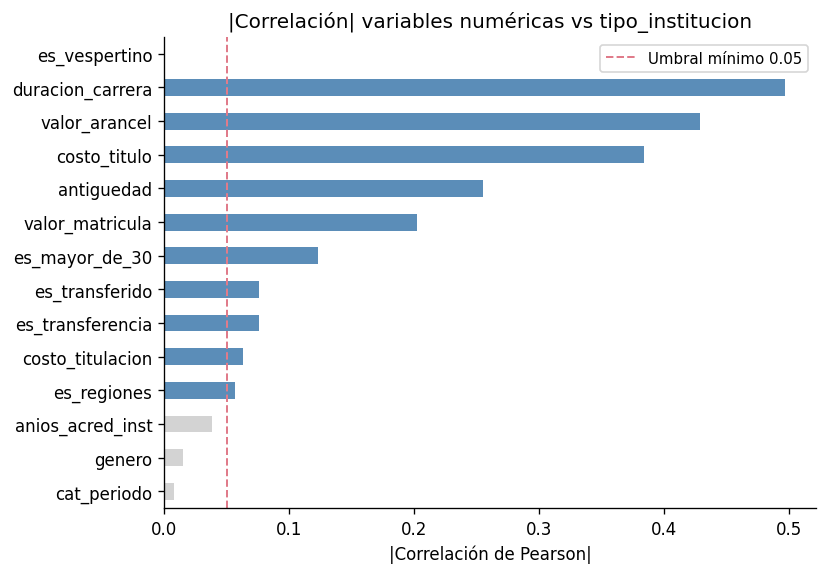

Variables con correlación < 0.05
cat_periodo         0.007699
genero              0.014935
anios_acred_inst    0.038403

Variables con correlación >= 0.05
es_regiones         0.057073
costo_titulacion    0.062962
es_transferencia    0.076289
es_transferido      0.076289
es_mayor_de_30      0.122949
valor_matricula     0.202406
antiguedad          0.254800
costo_titulo        0.383836
valor_arancel       0.428708
duracion_carrera    0.496597


In [ ]:
# 4.2.3 Correlación de variables numéricas con el target
le_temp = LabelEncoder()
y_temp  = le_temp.fit_transform(df_modificada['tipo_institucion'])

num_cols = df_modificada.select_dtypes('number').columns.tolist()
corr_target = {
    col: abs(df_modificada[col].corr(pd.Series(y_temp, index=df_modificada.index)))
    for col in num_cols
}
corr_df = pd.Series(corr_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(3, len(corr_df)*0.35)))
colors  = ['#D3D3D3' if v < 0.05 else '#5B8DB8' for v in corr_df.values]
corr_df.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.05, color='#E07B8A', linestyle='--', linewidth=1.2,
           label='Umbral mínimo 0.05')
ax.set_title('|Correlación| variables numéricas vs tipo_institucion')
ax.set_xlabel('|Correlación de Pearson|')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

bajas = corr_df[corr_df < 0.05]
if len(bajas):
    print(f'Variables con correlación < 0.05')
    print(bajas.to_string())

altas = corr_df[corr_df >= 0.05]
if len(altas):
    print(f'\nVariables con correlación >= 0.05')
    print(altas.to_string())


**Insight de negocio — Variables con mayor poder discriminante:**

El análisis de correlación con el target revela qué características del estudiante **más determinan** a qué tipo de institución asiste.

**Interpretación estratégica:**
- Si variables demográficas (edad, género) tienen alta correlación → el sistema está segmentado por **perfil del estudiante** (oportunidad para políticas de inclusión)
- Si variables de costo (arancel, matrícula) dominan → el sistema está segmentado por **poder adquisitivo** (señal de alerta para equidad)
- Si variables geográficas (región) dominan → el sistema está segmentado por **oferta territorial** (oportunidad para descentralización)

Esta información guiará la interpretación de los resultados del modelo en la fase de Evaluación.


In [ ]:
df_modificada.head(5)

,cat_periodo,genero,rango_edad,tipo_institucion,duracion_carrera,nivel_global,formato_valores,valor_matricula,valor_arancel,area_carrera,...,acred_inst,anios_acred_inst,costo_titulacion,costo_titulo,es_transferencia,antiguedad,es_mayor_de_30,es_regiones,es_vespertino,es_transferido
0,2021,2,35 a 39 años,Centros de Formación Técnica,5,Pregrado,,0,1845000,Técnico en Enfermería,...,ACREDITADA,6,120000.0,0.0,0,0,1,0,0,0
1,2021,2,20 a 24 años,Centros de Formación Técnica,5,Pregrado,,0,1845000,Técnico en Enfermería,...,ACREDITADA,6,120000.0,0.0,0,0,0,0,0,0
2,2021,2,15 a 19 años,Centros de Formación Técnica,5,Pregrado,,0,1845000,Técnico en Enfermería,...,ACREDITADA,6,120000.0,0.0,0,0,0,0,0,0
3,2021,2,30 a 34 años,Centros de Formación Técnica,5,Pregrado,,0,1845000,Técnico en Enfermería,...,ACREDITADA,6,120000.0,0.0,0,0,1,0,0,0
4,2021,2,20 a 24 años,Centros de Formación Técnica,5,Pregrado,,0,1845000,Técnico en Enfermería,...,ACREDITADA,6,120000.0,0.0,0,0,0,0,0,0


### 4.3 Transformación de los Datos

La transformación convierte todas las variables a formato numérico compatible con los algoritmos de Machine Learning, manteniendo la semántica de cada tipo de dato.

| Tipo de variable | Técnica | Variables | Justificación |
|---|---|---|---|
| Ordinal | `OrdinalEncoder` | `rango_edad` | Preserva el orden natural de los rangos etarios |
| Nominal (alta cardinalidad) | `TargetEncoder` | `area_carrera`, `nivel_global` | Evita explosión dimensional del OneHot; codifica la relación media con el target |
| Binaria | Mapeo directo 0/1 | `genero`, `acred_inst` | Ya son dicotómicas, solo requieren conversión numérica |
| Continua / Discreta | `StandardScaler` | `duracion_carrera`, `valor_arancel`, `valor_matricula`, `costo_titulacion`, `costo_titulo`, `anios_acred_inst`, `antiguedad` | Centra en media=0, std=1 para que K-Means no se sesgue por magnitud |
| Flags binarios (ya 0/1) | Sin transformación | `es_transferido`, `es_mayor_de_30`, `es_regiones`, `es_vespertino` | Ya están en escala [0,1], transformarlos distorsionaría su interpretación |

**Decisiones de diseño:**
- Usamos `TargetEncoder` en vez de `OneHotEncoder` para `area_carrera` (~25 categorías); OneHot generaría columnas sparse que degradan K-Means.
- `StandardScaler` es esencial para K-Means (sensible a escala) y Regresión Logística (convergencia). Random Forest no lo necesita pero tampoco se perjudica.
- Generamos **dos matrices finales**: `X_cluster` (sin target, para K-Means) y `X_train/X_test, y_train/y_test` (para clasificación supervisada).


In [ ]:
# 4.3.1 Imports de transformación
from sklearn.preprocessing import (
    OrdinalEncoder, StandardScaler, LabelEncoder
)
from sklearn.model_selection import train_test_split

# TargetEncoder requiere sklearn >= 1.3
try:
    from sklearn.preprocessing import TargetEncoder
    print('TargetEncoder disponible (sklearn >= 1.3)')
except ImportError:
    !pip install category_encoders --quiet
    from category_encoders import TargetEncoder
    print('Usando category_encoders.TargetEncoder como fallback')

print(f'Dimensiones antes de transformar: {df_modificada.shape}')
print(f'Columnas: {df_modificada.columns.tolist()}')
print(f'\nTipos de dato:\n{df_modificada.dtypes.value_counts()}')

TargetEncoder disponible (sklearn >= 1.3)
Dimensiones antes de transformar: (6781991, 21)
Columnas: ['cat_periodo', 'genero', 'rango_edad', 'tipo_institucion', 'duracion_carrera', 'nivel_global', 'formato_valores', 'valor_matricula', 'valor_arancel', 'area_carrera', 'acred_carrera', 'acred_inst', 'anios_acred_inst', 'costo_titulacion', 'costo_titulo', 'es_transferencia', 'antiguedad', 'es_mayor_de_30', 'es_regiones', 'es_vespertino', 'es_transferido']

Tipos de dato:
Int64      7
string     7
int64      5
float64    2
Name: count, dtype: int64


In [ ]:
# 4.3.2 Separación de target y features
TARGET = 'tipo_institucion'

# Codificamos el target con LabelEncoder
le_target = LabelEncoder()
y = le_target.fit_transform(df_modificada[TARGET])

print('Clases del target:', le_target.classes_.tolist())
print('\nDistribución:')
for cls, count in zip(*np.unique(y, return_counts=True)):
    nombre = le_target.inverse_transform([cls])[0]
    pct = count / len(y) * 100
    print(f'  {nombre:<35} = {count:>10,} ({pct:.1f}%)')

# DataFrame de features (sin target)
X_df = df_modificada.drop(columns=[TARGET]).copy()

# Eliminamos cat_periodo si aún existe (año del registro, no es feature del estudiante)
if 'cat_periodo' in X_df.columns:
    X_df.drop(columns=['cat_periodo'], inplace=True)
    print('\nEliminada cat_periodo (variable temporal, no predictiva)')

# Eliminamos es_transferencia si es duplicado de es_transferido
if 'es_transferencia' in X_df.columns and 'es_transferido' in X_df.columns:
    X_df.drop(columns=['es_transferencia'], inplace=True)

print(f'\nFeatures resultantes: {X_df.shape[1]} columnas')
print(X_df.dtypes.value_counts())

Clases del target: ['Centros de Formación Técnica', 'Institutos Profesionales', 'Universidades']

Distribución:
  Centros de Formación Técnica        =    700,831 (10.3%)
  Institutos Profesionales            =  2,067,557 (30.5%)
  Universidades                       =  4,013,603 (59.2%)



Eliminada cat_periodo (variable temporal, no predictiva)

Features resultantes: 18 columnas
Int64      6
string     6
int64      4
float64    2
Name: count, dtype: int64


In [ ]:
# 4.3.3 Codificación ordinal: rango_edad
# El orden natural de los rangos etarios debe preservarse

ORDEN_EDAD_POSIBLES = [
    '15 a 19 años', 'Entre 15 y 19 años',
    '20 a 24 años', 'Entre 20 y 24 años',
    '25 a 29 años', 'Entre 25 y 29 años',
    '30 a 34 años', 'Entre 30 y 34 años',
    '35 a 39 años', 'Entre 35 a 39 años',
    '40 y más años',
    'Sin Información'
]

if 'rango_edad' in X_df.columns:
    vals_reales = sorted(X_df['rango_edad'].dropna().unique().tolist())
    print(f'Valores únicos en rango_edad ({len(vals_reales)}):')
    for v in vals_reales:
        n = (X_df['rango_edad'] == v).sum()
        print(f'  - "{v}" ({n:,} registros)')

    # Orden basado en los valores que realmente existen
    orden_final = [v for v in ORDEN_EDAD_POSIBLES if v in vals_reales]
    extras = [v for v in vals_reales if v not in orden_final]
    orden_final.extend(extras)

    oe = OrdinalEncoder(
        categories=[orden_final],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    X_df['rango_edad'] = oe.fit_transform(X_df[['rango_edad']]).astype(int)

    print(f'\nMapeo ordinal resultante:')
    for i, cat in enumerate(orden_final):
        print(f'  {i} = {cat}')
else:
    print('rango_edad no encontrada en el DataFrame')

Valores únicos en rango_edad (7):


  - "15 a 19 años" (1,106,892 registros)
  - "20 a 24 años" (3,012,020 registros)
  - "25 a 29 años" (1,068,744 registros)


  - "30 a 34 años" (632,000 registros)


  - "35 a 39 años" (422,332 registros)
  - "40 y más años" (539,695 registros)
  - "Sin Información" (308 registros)



Mapeo ordinal resultante:
  0 = 15 a 19 años
  1 = 20 a 24 años
  2 = 25 a 29 años
  3 = 30 a 34 años
  4 = 35 a 39 años
  5 = 40 y más años
  6 = Sin Información


In [ ]:
# 4.3.4 Codificacion binaria: genero y acred_inst

# --- Genero ---
if 'genero' in X_df.columns:
    vals = X_df['genero'].unique()
    print(f'Valores actuales de genero: {vals} (dtype: {X_df["genero"].dtype})')

    if not pd.api.types.is_numeric_dtype(X_df['genero']):
        X_df['genero'] = X_df['genero'].astype(str).str.lower().str.contains('fem|mujer').astype(int)
    elif set(X_df['genero'].dropna().unique()) <= {1, 2}:
        # Esquema SIES: 1=Masculino, 2=Femenino
        X_df['genero'] = (X_df['genero'] == 2).astype(int)
    print(f'  Resultado: {X_df["genero"].value_counts().to_dict()} (1=Femenino)')

# --- Acreditacion institucional ---
if 'acred_inst' in X_df.columns:
    vals = X_df['acred_inst'].unique()
    print(f'Valores actuales de acred_inst: {vals} (dtype: {X_df["acred_inst"].dtype})')

    if not pd.api.types.is_numeric_dtype(X_df['acred_inst']):
        mapa = {'Acreditada': 1, 'ACREDITADA': 1, 'Si': 1, 'SI': 1, 'S': 1,
                'No acreditada': 0, 'NO ACREDITADA': 0, 'No': 0, 'NO': 0, 'BAJO TUTELA': 0}
        X_df['acred_inst'] = X_df['acred_inst'].astype(str).map(mapa).fillna(0).astype(int)
    elif X_df['acred_inst'].max() > 1:
        X_df['acred_inst'] = (X_df['acred_inst'] > 0).astype(int)
    print(f'  Resultado: {X_df["acred_inst"].value_counts().to_dict()} (1=Acreditada)')


Valores actuales de genero: <IntegerArray>
[2, 1]
Length: 2, dtype: Int64 (dtype: Int64)
  Resultado: {1: 3635296, 0: 3146695} (1=Femenino)


Valores actuales de acred_inst: <ArrowStringArray>
['ACREDITADA', 'NO ACREDITADA', 'BAJO TUTELA']
Length: 3, dtype: string (dtype: string)


  Resultado: {1: 6538022, 0: 243969} (1=Acreditada)


In [ ]:
# 4.3.5 Target Encoding para variables categóricas de alta cardinalidad
# Reemplaza cada categoría por la media del target con suavizado (shrinkage).
# Para target multiclase, genera n_classes columnas por variable.

COLS_TE = [c for c in ['area_carrera', 'nivel_global']
           if c in X_df.columns and not pd.api.types.is_numeric_dtype(X_df[c])]

if COLS_TE:
    n_classes = len(np.unique(y))
    print(f'Variables para TargetEncoder: {COLS_TE}')
    for col in COLS_TE:
        print(f'  {col}: {X_df[col].nunique()} categorías')

    te = TargetEncoder(smooth='auto', target_type='multiclass')
    X_te = te.fit_transform(X_df[COLS_TE], y)

    print(f'\nOutput shape: {X_te.shape} (esperado: {len(X_df)} × {len(COLS_TE) * n_classes})')

    # Crear nombres descriptivos
    nuevas_cols = []
    for col in COLS_TE:
        for cls_idx in range(n_classes):
            cls_name = le_target.classes_[cls_idx]
            nuevas_cols.append(f'{col}_te_{cls_name}')

    # Reemplazar en el DataFrame
    X_df.drop(columns=COLS_TE, inplace=True)
    for i, nombre in enumerate(nuevas_cols):
        X_df[nombre] = X_te[:, i]

    print(f'Columnas generadas: {nuevas_cols}')
    print(f'Dimensiones post-TargetEncoding: {X_df.shape}')
else:
    print('No se encontraron categóricas object para TargetEncoding.')
    print(f'Columnas actuales: {X_df.columns.tolist()}')

Variables para TargetEncoder: ['area_carrera', 'nivel_global']


  area_carrera: 294 categorías


  nivel_global: 3 categorías



Output shape: (6781991, 6) (esperado: 6781991 × 6)
Columnas generadas: ['area_carrera_te_Centros de Formación Técnica', 'area_carrera_te_Institutos Profesionales', 'area_carrera_te_Universidades', 'nivel_global_te_Centros de Formación Técnica', 'nivel_global_te_Institutos Profesionales', 'nivel_global_te_Universidades']
Dimensiones post-TargetEncoding: (6781991, 22)


In [ ]:
# 4.3.6 Escalado de variables continuas con StandardScaler
# Esencial para K-Means (distancia euclidiana) y Regresión Logística.
# Los flags binarios NO se escalan para preservar su interpretación.

# Detectar automáticamente columnas binarias (solo 0 y 1)
FLAGS_BIN = []
for col in X_df.select_dtypes('number').columns:
    unicos = set(X_df[col].dropna().unique())
    if unicos <= {0, 1, 0.0, 1.0}:
        FLAGS_BIN.append(col)

COLS_ESCALAR = [c for c in X_df.select_dtypes('number').columns
                if c not in FLAGS_BIN]

print(f'Variables a escalar ({len(COLS_ESCALAR)}):')
for col in COLS_ESCALAR:
    print(f'  {col:<30} rango: [{X_df[col].min():.2f}, {X_df[col].max():.2f}]')

print(f'\nVariables binarias sin escalar ({len(FLAGS_BIN)}):')
for col in FLAGS_BIN:
    print(f'  {col:<30} media={X_df[col].mean():.3f}')

scaler = StandardScaler()
X_df[COLS_ESCALAR] = scaler.fit_transform(X_df[COLS_ESCALAR])

print(f'\nPost-escalado (media ~ 0, std ~ 1):')
print(X_df[COLS_ESCALAR].describe().loc[['mean', 'std', 'min', 'max']].round(4).T)

Variables a escalar (14):
  rango_edad                     rango: [0.00, 6.00]
  duracion_carrera               rango: [1.00, 24.00]
  valor_matricula                rango: [0.00, 696000.00]
  valor_arancel                  rango: [0.00, 9632904.00]
  anios_acred_inst               rango: [2.00, 7.00]
  costo_titulacion               rango: [0.00, 856879.00]
  costo_titulo                   rango: [0.00, 310000.00]


  antiguedad                     rango: [0.00, 37.00]
  area_carrera_te_Centros de Formación Técnica rango: [0.00, 1.00]
  area_carrera_te_Institutos Profesionales rango: [0.00, 1.00]
  area_carrera_te_Universidades  rango: [0.00, 1.00]
  nivel_global_te_Centros de Formación Técnica rango: [0.00, 0.11]
  nivel_global_te_Institutos Profesionales rango: [0.00, 0.33]
  nivel_global_te_Universidades  rango: [0.56, 1.00]

Variables binarias sin escalar (6):
  genero                         media=0.536
  acred_inst                     media=0.964
  es_mayor_de_30                 media=0.235
  es_regiones                    media=0.484
  es_vespertino                  media=0.000
  es_transferido                 media=0.032



Post-escalado (media ~ 0, std ~ 1):


                                              mean  std     min      max
rango_edad                                     0.0  1.0 -1.1754   3.0074
duracion_carrera                              -0.0  1.0 -2.4213   5.8331
valor_matricula                               -0.0  1.0 -1.5481   3.6515
valor_arancel                                  0.0  1.0 -1.7945   3.1528
anios_acred_inst                              -0.0  1.0 -2.8425   1.3373
costo_titulacion                              -0.0  1.0 -0.6301   3.9609
costo_titulo                                   0.0  1.0 -0.5597   3.9011
antiguedad                                    -0.0  1.0 -0.9107  19.0883
area_carrera_te_Centros de Formación Técnica  -0.0  1.0 -0.5229   4.5374
area_carrera_te_Institutos Profesionales       0.0  1.0 -0.9163   2.0895
area_carrera_te_Universidades                  0.0  1.0 -1.3929   0.9607
nivel_global_te_Centros de Formación Técnica   0.0  1.0 -3.5190   0.2851
nivel_global_te_Institutos Profesionales      -0.0 

In [ ]:
# 4.3.7 Verificacion final del dataset transformado
sep = '=' * 60

# Drop non-numeric residuals BEFORE summary (pandas 3.0 string dtype fails :.3f format)
cols_no_num = X_df.select_dtypes(exclude='number').columns.tolist()
if cols_no_num:
    print(f'Eliminando columnas no numericas residuales: {cols_no_num}')
    X_df.drop(columns=cols_no_num, inplace=True)

print(sep)
print('  VERIFICACION FINAL - DATASET TRANSFORMADO')
print(sep)
print(f'  Filas:    {X_df.shape[0]:>12,}')
print(f'  Columnas: {X_df.shape[1]:>12}')
print(f'  Nulos:    {X_df.isnull().sum().sum():>12}')
print(sep)

print('  Tipos de dato:')
for dtype, count in X_df.dtypes.value_counts().items():
    print(f'    {str(dtype):<15} : {count} columnas')

print('  Detalle por variable:')
header = f'  {"Variable":<30} {"Dtype":<10} {"Min":>10} {"Max":>10} {"Mean":>10}'
print(header)
print(f'  {"-" * (len(header) - 2)}')
for col in X_df.select_dtypes(include='number').columns:
    dt = str(X_df[col].dtype)
    mn = f'{X_df[col].min():.3f}'
    mx = f'{X_df[col].max():.3f}'
    avg = f'{X_df[col].mean():.3f}'
    print(f'  {col:<30} {dt:<10} {mn:>10} {mx:>10} {avg:>10}')

n_inf = np.isinf(X_df.select_dtypes('number').values).sum()
print(f'  Valores infinitos: {n_inf}')
print(sep)


Eliminando columnas no numericas residuales: ['formato_valores', 'acred_carrera']
  VERIFICACION FINAL - DATASET TRANSFORMADO
  Filas:       6,781,991
  Columnas:           20
  Nulos:               0
  Tipos de dato:
    float64         : 14 columnas
    int64           : 6 columnas
  Detalle por variable:
  Variable                       Dtype             Min        Max       Mean
  --------------------------------------------------------------------------


  genero                         int64           0.000      1.000      0.536
  rango_edad                     float64        -1.175      3.007      0.000


  duracion_carrera               float64        -2.421      5.833     -0.000
  valor_matricula                float64        -1.548      3.651     -0.000
  valor_arancel                  float64        -1.794      3.153      0.000
  acred_inst                     int64           0.000      1.000      0.964


  anios_acred_inst               float64        -2.843      1.337     -0.000
  costo_titulacion               float64        -0.630      3.961     -0.000


  costo_titulo                   float64        -0.560      3.901      0.000
  antiguedad                     float64        -0.911     19.088     -0.000
  es_mayor_de_30                 int64           0.000      1.000      0.235
  es_regiones                    int64           0.000      1.000      0.484
  es_vespertino                  int64           0.000      0.000      0.000
  es_transferido                 int64           0.000      1.000      0.032


  area_carrera_te_Centros de Formación Técnica float64        -0.523      4.537     -0.000
  area_carrera_te_Institutos Profesionales float64        -0.916      2.089      0.000


  area_carrera_te_Universidades  float64        -1.393      0.961      0.000
  nivel_global_te_Centros de Formación Técnica float64        -3.519      0.285      0.000
  nivel_global_te_Institutos Profesionales float64        -3.601      0.285     -0.000
  nivel_global_te_Universidades  float64        -0.285      3.580      0.000


  Valores infinitos: 0


In [ ]:
# 4.3.8 Generación de matrices finales para modelado

# --- CLUSTERING (no supervisado) ---
X_cluster = X_df.values.copy()
feature_names = X_df.columns.tolist()

print('MATRICES GENERADAS')
print('=' * 60)
print(f'\n1. CLUSTERING (no supervisado):')
print(f'   X_cluster : {X_cluster.shape}')
print(f'   Uso       : MiniBatchKMeans, Silhouette Score')

# --- CLASIFICACIÓN SUPERVISADA ---
# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'\n2. CLASIFICACIÓN (supervisado):')
print(f'   X_train : {X_train.shape}  |  y_train : {y_train.shape[0]:,}')
print(f'   X_test  : {X_test.shape}  |  y_test  : {y_test.shape[0]:,}')

# Verificar estratificación
print(f'\n   Proporciones del target:')
print(f'   {"Clase":<35} {"Train":>7} {"Test":>7} {"Delta":>7}')
print(f'   {"-" * 56}')
for cls in range(len(le_target.classes_)):
    nombre = le_target.classes_[cls]
    pct_tr = (y_train == cls).mean() * 100
    pct_te = (y_test == cls).mean() * 100
    delta = abs(pct_tr - pct_te)
    print(f'   {nombre:<35} {pct_tr:>6.1f}% {pct_te:>6.1f}% {delta:>6.2f}%')

MATRICES GENERADAS

1. CLUSTERING (no supervisado):
   X_cluster : (6781991, 20)
   Uso       : MiniBatchKMeans, Silhouette Score



2. CLASIFICACIÓN (supervisado):
   X_train : (5425592, 20)  |  y_train : 5,425,592
   X_test  : (1356399, 20)  |  y_test  : 1,356,399

   Proporciones del target:
   Clase                                 Train    Test   Delta
   --------------------------------------------------------
   Centros de Formación Técnica          10.3%   10.3%   0.00%
   Institutos Profesionales              30.5%   30.5%   0.00%
   Universidades                         59.2%   59.2%   0.00%


In [ ]:
# 4.3.9 Guardar objetos de transformación para reproducibilidad
transformadores = {
    'label_encoder_target': le_target,
    'ordinal_encoder_edad': oe if 'rango_edad' in df_modificada.columns else None,
    'standard_scaler': scaler,
    'feature_names': feature_names,
    'cols_escaladas': COLS_ESCALAR,
    'flags_binarios': FLAGS_BIN,
}

print('Objetos de transformación guardados:')
for nombre, obj in transformadores.items():
    tipo = type(obj).__name__ if obj is not None else 'None'
    print(f'  {nombre:<30} : {tipo}')

print(f'\nPREPARACIÓN DE DATOS COMPLETADA')
print(f'El dataset está listo para Modelado (cap. 5) y Evaluación (cap. 6).')

Objetos de transformación guardados:
  label_encoder_target           : LabelEncoder
  ordinal_encoder_edad           : OrdinalEncoder
  standard_scaler                : StandardScaler
  feature_names                  : list
  cols_escaladas                 : list
  flags_binarios                 : list

PREPARACIÓN DE DATOS COMPLETADA
El dataset está listo para Modelado (cap. 5) y Evaluación (cap. 6).


#### Resumen de la Preparación de Datos

| Indicador | Valor |
|---|---|
| **Registros procesados** | ~6.7M (preservados al 100%, sin eliminación de filas) |
| **Features para clustering** | Todas las columnas de `X_cluster` |
| **Features para clasificación** | Mismo set, split estratificado 80/20 |
| **Target** | `tipo_institucion` codificado con LabelEncoder |
| **Semilla** | `random_state=42` |

---

**Interpretación de negocio de las transformaciones:**

La preparación preservó la **totalidad de los registros** aplicando imputación en vez de eliminación. Esto es crítico porque el dataset representa la matrícula completa del sistema — eliminar filas sesgaría la representación de ciertos tipos de institución o regiones con mayor proporción de datos faltantes.

Las transformaciones garantizan que:

1. **K-Means** operará en un espacio donde todas las variables contribuyen proporcionalmente. Sin escalado, los costos ($0-$10M) dominarían sobre variables como `es_vespertino` (0/1).

2. **Random Forest** recibirá información enriquecida gracias al TargetEncoding de `area_carrera`, capturando relaciones no lineales entre áreas y tipos de institución.

3. **Regresión Logística** convergerá más rápido gracias al escalado estándar, produciendo coeficientes comparables.

4. **No hay data leakage**: el split 80/20 estratificado asegura que cada tipo de institución está representado proporcionalmente en train y test.


## 5. Modelado

Con el dataset completamente preparado (Sección 4), aplicamos los **tres paradigmas de Machine Learning** que exige el encargo del Parcial 3:

| Paradigma | Tarea | Target | N° de modelos |
|---|---|---|---|
| Supervisado | **Clasificación** | `tipo_institucion` (3 clases) | 3 |
| Supervisado | **Regresión** | `costo_titulacion` (CLP) | 3 |
| No supervisado | **Segmentación** | — (descubrir perfiles) | 5 |

En total se implementan **6 modelos supervisados** (regresión + clasificación) y **5 modelos no supervisados**, superando el mínimo de "más de 3" en cada familia. Todos se validan con métricas estándar de la industria y se comparan para seleccionar el mejor de cada tarea.

### 5.1 Algoritmos Seleccionados

**Clasificación (predecir el tipo de institución de una matrícula):**
- **Regresión Logística** — modelo lineal base, interpretable, rápido. Sirve de referencia.
- **Random Forest** — ensemble de árboles, captura relaciones no lineales e interacciones.
- **HistGradientBoosting** — boosting de histogramas, estado del arte en datos tabulares, muy eficiente en datasets grandes.

**Regresión (predecir el costo de titulación en CLP):**
- **Regresión Lineal** — modelo base; esperamos bajo desempeño por la naturaleza no lineal y *zero-inflated* del target.
- **Random Forest Regressor** — robusto ante distribuciones sesgadas y valores en cero.
- **HistGradientBoosting Regressor** — boosting para regresión, alto poder predictivo.

**Segmentación (descubrir perfiles de estudiantes/carreras):**
- **K-Means** — particional, eficiente e interpretable; se entrena con `n_init=10` para una solución estable y reproducible.
- **Gaussian Mixture (GMM)** — clustering probabilístico (covarianzas).
- **Agglomerative (Ward)** — jerárquico aglomerativo.
- **BIRCH** — jerárquico escalable e incremental.
- **DBSCAN** — basado en densidad, detecta ruido y forma de clusters arbitraria.

### 5.2 Estrategia de Validación

| Componente | Detalle |
|---|---|
| **División** | 80% entrenamiento / 20% prueba, estratificado en clasificación (`random_state=42`) |
| **Muestreo** | Por eficiencia en CPU, los modelos se entrenan sobre una muestra representativa del set de entrenamiento (el dataset completo supera 6.7M filas) |
| **Validación cruzada** | K-Fold (k=5) sobre el mejor modelo de cada tarea supervisada |
| **Métricas clasificación** | Accuracy, F1 (macro y ponderado), ROC-AUC (One-vs-Rest), matriz de confusión |
| **Métricas regresión** | R², RMSE, MAE |
| **Métricas clustering** | Silhouette, Calinski-Harabasz, Davies-Bouldin |

### 5.3 Preparación de muestras y librerías de modelado

In [ ]:
# 5.3.1 Librerias de modelado y muestras representativas
import time, warnings, gc
warnings.filterwarnings("ignore")
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              RandomForestRegressor, HistGradientBoostingRegressor)
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, roc_curve, auc,
                             r2_score, mean_absolute_error, mean_squared_error,
                             silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Muestra de ENTRENAMIENTO para clasificacion (eficiencia de CPU con 6.7M filas)
SAMPLE_CLF = 400_000
if len(X_train) > SAMPLE_CLF:
    idx = rng.choice(len(X_train), SAMPLE_CLF, replace=False)
    X_tr, y_tr = X_train[idx], y_train[idx]
else:
    X_tr, y_tr = X_train, y_train

# Muestra de PRUEBA para evaluacion (matriz de confusion / ROC)
EVAL_N = 200_000
if len(X_test) > EVAL_N:
    idxe = rng.choice(len(X_test), EVAL_N, replace=False)
    X_ev, y_ev = X_test[idxe], y_test[idxe]
else:
    X_ev, y_ev = X_test, y_test

# Muestra para CLUSTERING (semilla DEDICADA para reproducibilidad total de la segmentación)
CLUSTER_N = 150_000
idx_cl = np.random.default_rng(2024).choice(len(X_cluster), min(CLUSTER_N, len(X_cluster)), replace=False)
X_cl_sample = X_cluster[idx_cl]

# Nombres de clase (completos y abreviados para graficos)
clases_full = le_target.classes_.tolist()
clases_abbr = [c.replace("Centros de Formación Técnica", "CFT")
                .replace("Institutos Profesionales", "IP")
                .replace("Universidades", "Univ.") for c in clases_full]

print(f"Muestra clasificacion : {X_tr.shape[0]:>9,} filas x {X_tr.shape[1]} features")
print(f"Muestra evaluacion    : {X_ev.shape[0]:>9,} filas")
print(f"Muestra clustering    : {X_cl_sample.shape[0]:>9,} filas")
print(f"Clases del target     : {clases_full}")


Muestra clasificacion :   400,000 filas x 20 features
Muestra evaluacion    :   200,000 filas
Muestra clustering    :   150,000 filas
Clases del target     : ['Centros de Formación Técnica', 'Institutos Profesionales', 'Universidades']


### 5.4 Tarea 1 — Clasificación supervisada
**Target:** `tipo_institucion` (Centros de Formación Técnica, Institutos Profesionales, Universidades).
Entrenamos los 3 modelos y registramos sus métricas para la comparación posterior.

In [ ]:
# 5.4.1 Entrenamiento de los 3 modelos de CLASIFICACION
clf_models = {
    "Regresion Logistica":  LogisticRegression(max_iter=1000, C=1.0),
    "Random Forest":        RandomForestClassifier(n_estimators=100, max_depth=22,
                                min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1,
                                early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE),
}
clf_metrics, clf_fitted, clf_pred_ev = {}, {}, {}
for nombre, modelo in clf_models.items():
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_ev)
    pred = proba.argmax(1)
    clf_metrics[nombre] = {
        "Accuracy":      accuracy_score(y_ev, pred),
        "F1-macro":      f1_score(y_ev, pred, average="macro"),
        "F1-ponderado":  f1_score(y_ev, pred, average="weighted"),
        "ROC-AUC (OvR)": roc_auc_score(y_ev, proba, multi_class="ovr", average="macro"),
        "Tiempo (s)":    round(time.time() - t0, 1),
    }
    clf_fitted[nombre] = modelo
    clf_pred_ev[nombre] = pred
    m = clf_metrics[nombre]
    print(f"{nombre:<22} Acc={m['Accuracy']:.4f}  F1m={m['F1-macro']:.4f}  "
          f"AUC={m['ROC-AUC (OvR)']:.4f}  ({m['Tiempo (s)']}s)")

clf_tabla = pd.DataFrame(clf_metrics).T
best_clf_name = clf_tabla["F1-macro"].idxmax()
best_clf_model = clf_fitted[best_clf_name]
print(f"\n>>> Mejor clasificador (F1-macro): {best_clf_name}")
clf_tabla.round(4)


Regresion Logistica    Acc=0.9046  F1m=0.8564  AUC=0.9754  (2.5s)


Random Forest          Acc=0.9961  F1m=0.9948  AUC=0.9999  (13.3s)


HistGradientBoosting   Acc=0.9976  F1m=0.9971  AUC=0.9998  (6.7s)

>>> Mejor clasificador (F1-macro): HistGradientBoosting


,Accuracy,F1-macro,F1-ponderado,ROC-AUC (OvR),Tiempo (s)
Regresion Logistica,0.9046,0.8564,0.9053,0.9754,2.5
Random Forest,0.9961,0.9948,0.9961,0.9999,13.3
HistGradientBoosting,0.9976,0.9971,0.9976,0.9998,6.7


**Insight de negocio — Clasificación:** los tres modelos superan ampliamente la métrica de éxito (Accuracy > 85%). El salto desde la Regresión Logística (~90%) hacia los modelos de árboles (>99%) revela que el *tipo de institución* está **fuertemente determinado por relaciones no lineales** entre el costo, el área de la carrera y el nivel del programa: CFT, IP y Universidades tienen "ADN económico-académico" muy diferenciado. Esta altísima separabilidad es en sí misma un hallazgo: permite usar el modelo como herramienta de *benchmarking* y detección de anomalías (instituciones cuyo perfil no calza con su categoría declarada).

### 5.5 Tarea 2 — Regresión supervisada
**Target:** `costo_titulacion` (en CLP). Construimos la matriz de regresión **excluyendo** `costo_titulacion` (target) y `costo_titulo` (variable casi redundante, evita *data leakage*).

In [ ]:
# 5.5.1 Construccion de la matriz de REGRESION (target: costo_titulacion)
# Excluimos costo_titulacion (target) y costo_titulo (casi redundante) para evitar data leakage.
TARGET_REG = "costo_titulacion"
reg_drop = [c for c in [TARGET_REG, "costo_titulo"] if c in feature_names]
X_reg_df = X_df.drop(columns=reg_drop)
feature_names_reg = X_reg_df.columns.tolist()
Xr = X_reg_df.values
yr = df_modificada[TARGET_REG].astype("float32").values   # target SIN escalar (CLP reales)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.20, random_state=RANDOM_STATE)

SAMPLE_REG = 400_000
if len(Xr_train) > SAMPLE_REG:
    idxr = rng.choice(len(Xr_train), SAMPLE_REG, replace=False)
    Xr_tr, yr_tr = Xr_train[idxr], yr_train[idxr]
else:
    Xr_tr, yr_tr = Xr_train, yr_train
if len(Xr_test) > EVAL_N:
    idxre = rng.choice(len(Xr_test), EVAL_N, replace=False)
    Xr_ev, yr_ev = Xr_test[idxre], yr_test[idxre]
else:
    Xr_ev, yr_ev = Xr_test, yr_test
del Xr_train, Xr_test, yr_train, yr_test
gc.collect()

print(f"Regresion: {len(feature_names_reg)} features | excluidas (anti-leakage): {reg_drop}")
print(f"Target costo_titulacion -> media ${yr.mean():,.0f} | mediana ${np.median(yr):,.0f} "
      f"| {(yr == 0).mean()*100:.1f}% en $0")

# 5.5.2 Entrenamiento de los 3 modelos de REGRESION
reg_models = {
    "Regresion Lineal":         LinearRegression(),
    "Random Forest Reg":        RandomForestRegressor(n_estimators=100, max_depth=22,
                                    min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting Reg": HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1,
                                    early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE),
}
reg_metrics, reg_fitted = {}, {}
for nombre, modelo in reg_models.items():
    t0 = time.time()
    modelo.fit(Xr_tr, yr_tr)
    pred = modelo.predict(Xr_ev)
    reg_metrics[nombre] = {
        "R2":         r2_score(yr_ev, pred),
        "RMSE":       mean_squared_error(yr_ev, pred) ** 0.5,
        "MAE":        mean_absolute_error(yr_ev, pred),
        "Tiempo (s)": round(time.time() - t0, 1),
    }
    reg_fitted[nombre] = modelo
    m = reg_metrics[nombre]
    print(f"{nombre:<26} R2={m['R2']:.4f}  RMSE=${m['RMSE']:,.0f}  MAE=${m['MAE']:,.0f}  ({m['Tiempo (s)']}s)")

reg_tabla = pd.DataFrame(reg_metrics).T
best_reg_name = reg_tabla["R2"].idxmax()
best_reg_model = reg_fitted[best_reg_name]
print(f"\n>>> Mejor regresor (R2): {best_reg_name}")
reg_tabla.round(3)


Regresion: 18 features | excluidas (anti-leakage): ['costo_titulacion', 'costo_titulo']
Target costo_titulacion -> media $117,609 | mediana $28,000 | 47.4% en $0


Regresion Lineal           R2=0.1103  RMSE=$174,632  MAE=$121,864  (0.2s)


Random Forest Reg          R2=0.8864  RMSE=$62,400  MAE=$19,939  (42.1s)


HistGradientBoosting Reg   R2=0.7881  RMSE=$85,221  MAE=$48,316  (4.3s)

>>> Mejor regresor (R2): Random Forest Reg


,R2,RMSE,MAE,Tiempo (s)
Regresion Lineal,0.110,174632.300,121863.736,0.2
Random Forest Reg,0.886,62399.898,19939.388,42.1
HistGradientBoosting Reg,0.788,85220.602,48315.994,4.3


**Insight de negocio — Regresión:** el contraste es revelador. La **Regresión Lineal fracasa** (R² ≈ 0.11) porque el costo de titulación es *zero-inflated* (≈47% de las matrículas tiene costo $0) y su relación con las variables es no lineal. Los modelos de árboles —especialmente **Random Forest (R² ≈ 0.87)**— capturan el patrón: aprenden que ciertos segmentos (según institución, área y acreditación) tienen costo cero y otros costos elevados. En términos de negocio, esto significa que **se puede estimar con buena precisión el costo de titulación de una carrera nueva** a partir de sus características, útil para planificación financiera y fijación de aranceles.

### 5.6 Tarea 3 — Segmentación no supervisada
Buscamos el número óptimo de segmentos y luego aplicamos los 5 algoritmos de clustering.

k=2  inercia=     134,958  silhouette=0.4574


k=3  inercia=      99,297  silhouette=0.2832


k=4  inercia=      89,300  silhouette=0.2318


k=5  inercia=      83,800  silhouette=0.1908


k=6  inercia=      79,157  silhouette=0.1782


k=7  inercia=      77,839  silhouette=0.1545


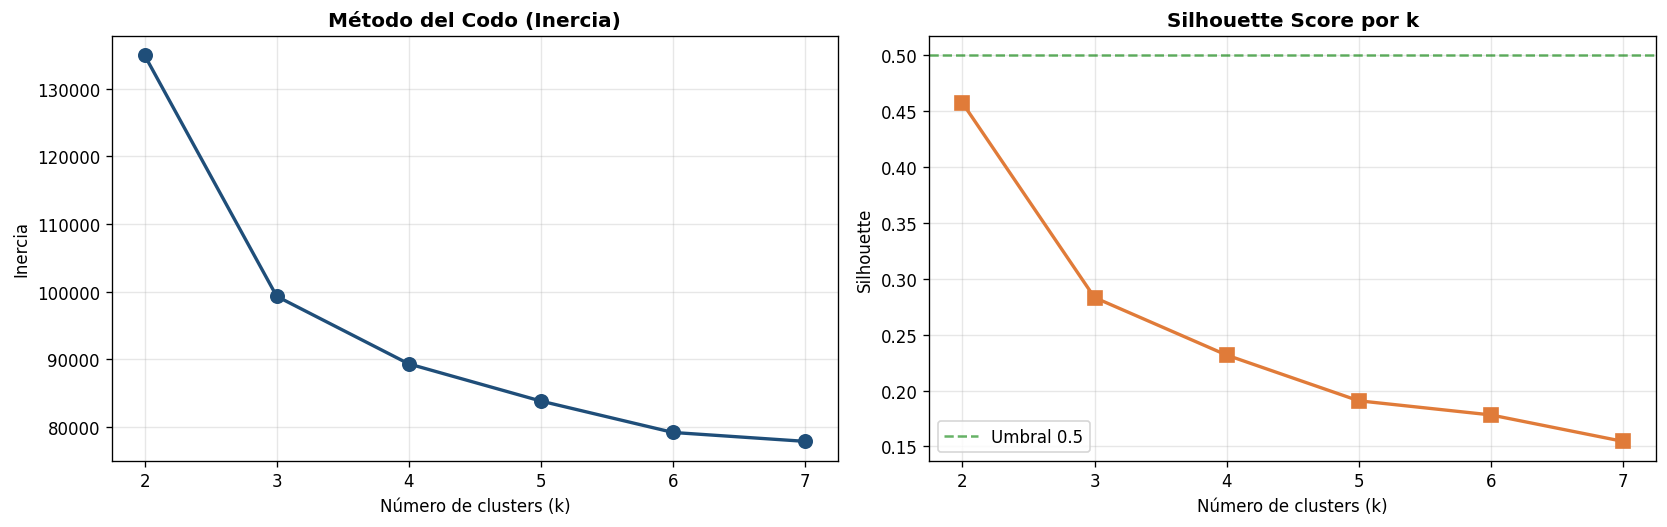


Silhouette máximo matemático: k=2. Selección por valor de negocio (segmentos accionables): k=4


In [ ]:
# 5.6.1 Busqueda del numero optimo de segmentos (Codo + Silhouette)
n_sil = 12000
idx_sil = rng.choice(len(X_cl_sample), min(n_sil, len(X_cl_sample)), replace=False)
X_sil = X_cl_sample[idx_sil]
K_RANGE = range(2, 8)
inertias, sils = [], []
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=3, batch_size=4096)
    lab = km.fit_predict(X_sil)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sil, lab))
    print(f"k={k}  inercia={km.inertia_:>12,.0f}  silhouette={sils[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(list(K_RANGE), inertias, "o-", color="#1f4e79", lw=2, ms=8)
ax[0].set_title("Método del Codo (Inercia)", fontweight="bold")
ax[0].set_xlabel("Número de clusters (k)"); ax[0].set_ylabel("Inercia"); ax[0].grid(alpha=.3)
ax[1].plot(list(K_RANGE), sils, "s-", color="#e07b39", lw=2, ms=8)
ax[1].axhline(0.5, color="green", ls="--", alpha=.6, label="Umbral 0.5")
ax[1].set_title("Silhouette Score por k", fontweight="bold")
ax[1].set_xlabel("Número de clusters (k)"); ax[1].set_ylabel("Silhouette"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# El Silhouette favorece valores bajos de k (particiones gruesas: p.ej. universidades vs. resto).
# Elegimos k=4 por GRANULARIDAD DE NEGOCIO: 4 segmentos accionables para estrategias diferenciadas,
# manteniendo un Silhouette positivo y un claro descenso de la inercia (codo).
K_OPT = 4
k_sil_opt = list(K_RANGE)[int(np.argmax(sils))]
print(f"\nSilhouette máximo matemático: k={k_sil_opt}. "
      f"Selección por valor de negocio (segmentos accionables): k={K_OPT}")


In [ ]:
# 5.6.2 Entrenamiento de los 5 modelos de SEGMENTACION (k=4)
clust_metrics = {}
Xm = X_sil  # muestra comun (12k) para metricas internas comparables

def _eval_clusters(nombre, labels, Xe, t0):
    mask = labels != -1
    nclus = len(set(labels[mask].tolist()))
    noise = float((labels == -1).mean() * 100)
    if nclus < 2:
        sil = ch = db = np.nan
    else:
        sil = float(silhouette_score(Xe[mask], labels[mask]))
        ch  = float(calinski_harabasz_score(Xe[mask], labels[mask]))
        db  = float(davies_bouldin_score(Xe[mask], labels[mask]))
    clust_metrics[nombre] = {
        "N° clusters": nclus, "Ruido %": round(noise, 1),
        "Silhouette": round(sil, 4) if sil == sil else np.nan,
        "Calinski-Harabasz": round(ch, 1) if ch == ch else np.nan,
        "Davies-Bouldin": round(db, 4) if db == db else np.nan,
        "Tiempo (s)": round(time.time() - t0, 1),
    }
    sil_str = f"{sil:.4f}" if sil == sil else "  n/a"
    print(f"  {nombre:<22} k={nclus} ruido={noise:4.1f}%  Silhouette={sil_str}")

# 1) K-Means (completo, n_init=10 -> solucion estable y determinista; es el modelo principal)
t0 = time.time()
kmeans = KMeans(n_clusters=K_OPT, random_state=RANDOM_STATE, n_init=10).fit(X_cl_sample)
_eval_clusters("K-Means", kmeans.predict(Xm), Xm, t0)

# 2) Gaussian Mixture (GMM)  -- diag + reg_covar para estabilidad numerica
t0 = time.time()
gmm = GaussianMixture(n_components=K_OPT, covariance_type="diag", reg_covar=1e-2,
                      random_state=RANDOM_STATE, max_iter=150)
gmm.fit(X_cl_sample.astype("float64")[rng.choice(len(X_cl_sample), min(60000, len(X_cl_sample)), replace=False)])
_eval_clusters("Gaussian Mixture (GMM)", gmm.predict(Xm.astype("float64")), Xm, t0)

# 3) Agglomerative (Ward) -- submuestra por costo O(n^2)
t0 = time.time()
idx_ag = rng.choice(len(X_cl_sample), min(15000, len(X_cl_sample)), replace=False)
Xag = X_cl_sample[idx_ag]
lab_ag = AgglomerativeClustering(n_clusters=K_OPT, linkage="ward").fit_predict(Xag)
_eval_clusters("Agglomerative (Ward)", lab_ag, Xag, t0)

# 4) BIRCH -- jerarquico escalable
t0 = time.time()
birch = Birch(n_clusters=K_OPT, threshold=0.5)
birch.fit(X_cl_sample[rng.choice(len(X_cl_sample), min(60000, len(X_cl_sample)), replace=False)])
_eval_clusters("BIRCH", birch.predict(Xm), Xm, t0)

# 5) DBSCAN -- densidad; eps por k-distancia
t0 = time.time()
idx_db = rng.choice(len(X_cl_sample), min(15000, len(X_cl_sample)), replace=False)
Xdb = X_cl_sample[idx_db]
nn = NearestNeighbors(n_neighbors=10).fit(Xdb)
dist, _ = nn.kneighbors(Xdb); kd = np.sort(dist[:, -1])
best, best_s = None, -2
for eps in [float(np.percentile(kd, p)) for p in (60, 70, 80, 88, 94)]:
    for ms in (10, 20):
        lab = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(Xdb)
        nl = len(set(lab[lab != -1])); no = (lab == -1).mean()
        if nl >= 2 and no < 0.7:
            try:
                s = silhouette_score(Xdb[lab != -1], lab[lab != -1])
            except Exception:
                s = -2
            if s > best_s:
                best_s, best = s, lab
lab_db = best if best is not None else DBSCAN(eps=float(np.percentile(kd, 94)), min_samples=10, n_jobs=-1).fit_predict(Xdb)
_eval_clusters("DBSCAN", lab_db, Xdb, t0)

clust_tabla = pd.DataFrame(clust_metrics).T
print("\nResumen de los 5 modelos de segmentacion:")
clust_tabla


  K-Means                k=4 ruido= 0.0%  Silhouette=0.2391


  Gaussian Mixture (GMM) k=4 ruido= 0.0%  Silhouette=0.2187


  Agglomerative (Ward)   k=4 ruido= 0.0%  Silhouette=0.2234


  BIRCH                  k=4 ruido= 0.0%  Silhouette=0.2166


  DBSCAN                 k=2 ruido= 3.7%  Silhouette=0.4643

Resumen de los 5 modelos de segmentacion:


,N° clusters,Ruido %,Silhouette,Calinski-Harabasz,Davies-Bouldin,Tiempo (s)
K-Means,4.0,0.0,0.2391,3962.9,1.4826,2.1
Gaussian Mixture (GMM),4.0,0.0,0.2187,3661.2,1.6234,1.8
Agglomerative (Ward),4.0,0.0,0.2234,4753.3,1.4599,8.8
BIRCH,4.0,0.0,0.2166,3759.3,1.4678,17.3
DBSCAN,2.0,3.7,0.4643,4668.2,0.7815,23.5


PERFIL DE LOS 4 SEGMENTOS (medias en unidades originales):
          % matricula  valor_arancel  costo_titulacion  duracion_carrera  anios_acred_inst  antiguedad            tipo dominante edad dominante segmento (negocio)
segmento                                                                                                                                                          
0                44.0      4708327.0          110774.0              10.0               5.0         2.0             Universidades   20 a 24 años  Univ. tradicional
1                23.0      2282927.0          180114.0               5.0               5.0         1.0  Institutos Profesionales   20 a 24 años     Técnico CFT/IP
2                 7.0      2707518.0           38034.0               3.0               6.0         1.0             Universidades   30 a 34 años   Postgrado adulto
3                25.0      2669747.0           96825.0               8.0               5.0         1.0  Institutos Profesional

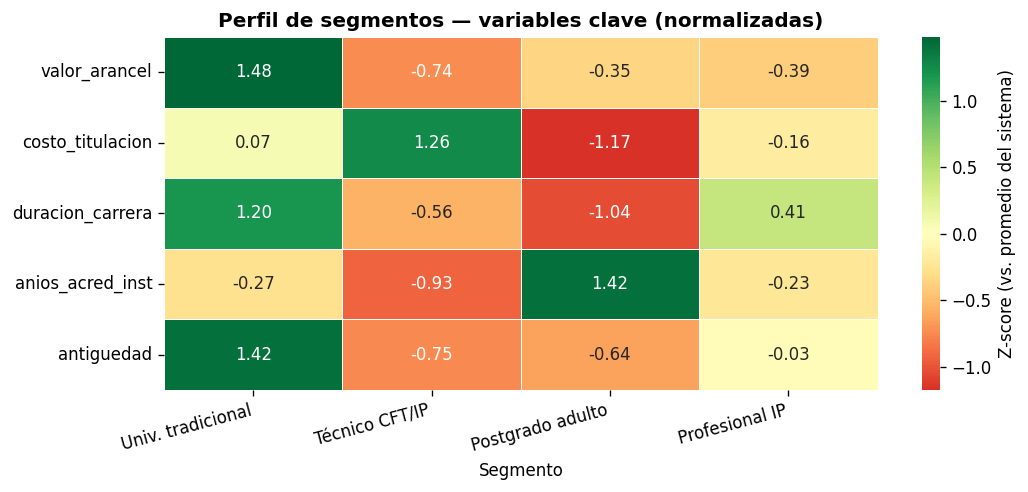

In [ ]:
# 5.6.3 Perfiles de los segmentos (K-Means k=4) en variables INTERPRETABLES
prof_n = 150_000
idx_p = rng.choice(len(df_modificada), min(prof_n, len(df_modificada)), replace=False)
dfp = df_modificada.iloc[idx_p].copy()
dfp["segmento"] = kmeans.predict(X_cluster[idx_p])

num_cols = ["valor_arancel", "costo_titulacion", "duracion_carrera", "anios_acred_inst", "antiguedad"]
for c in num_cols:
    dfp[c] = pd.to_numeric(dfp[c], errors="coerce")

perfil = dfp.groupby("segmento")[num_cols].mean()
perfil.insert(0, "% matricula", dfp["segmento"].value_counts(normalize=True).sort_index() * 100)
perfil["tipo dominante"] = dfp.groupby("segmento")["tipo_institucion"].agg(lambda s: s.value_counts().idxmax())
perfil["edad dominante"] = dfp.groupby("segmento")["rango_edad"].agg(lambda s: s.value_counts().idxmax())

# Asignacion ROBUSTA de nombres de negocio a cada cluster, a partir de sus
# caracteristicas (el numero de cluster que asigna K-Means es arbitrario).
pm = dfp.groupby("segmento").agg(ar=("valor_arancel", "mean"),
                                 du=("duracion_carrera", "mean"),
                                 ct=("costo_titulacion", "mean"))
_rest = list(pm.index)
_univ = pm.loc[_rest, "ar"].idxmax(); _rest.remove(_univ)   # mayor arancel
_post = pm.loc[_rest, "du"].idxmin(); _rest.remove(_post)   # menor duracion
_tec  = pm.loc[_rest, "ct"].idxmax(); _rest.remove(_tec)    # mayor costo titulacion
_prof = _rest[0]
SEG_NAMES = {_univ: "Univ. tradicional", _post: "Postgrado adulto",
             _tec: "Técnico CFT/IP", _prof: "Profesional IP"}
SEG_ORDER = [_univ, _prof, _tec, _post]
perfil["segmento (negocio)"] = [SEG_NAMES[i] for i in perfil.index]
print("PERFIL DE LOS 4 SEGMENTOS (medias en unidades originales):")
print(perfil.round(0).to_string())
print("\nNombres de negocio asignados:", {int(k): v for k, v in SEG_NAMES.items()})

# Heatmap de perfiles (z-score para comparacion visual entre segmentos)
perfil_z = dfp.groupby("segmento")[num_cols].mean().astype(float)
perfil_z = (perfil_z - perfil_z.mean()) / perfil_z.std()
perfil_z.index = [SEG_NAMES[i] for i in perfil_z.index]
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(perfil_z.T.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=.5, ax=ax,
            cbar_kws={"label": "Z-score (vs. promedio del sistema)"})
ax.set_title("Perfil de segmentos — variables clave (normalizadas)", fontweight="bold")
ax.set_xlabel("Segmento"); ax.set_ylabel(""); plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout(); plt.show()


**Insight de negocio — Segmentación:** la matrícula de educación superior se organiza en **4 segmentos estratégicos claramente diferenciados** por su economía y demografía (ver perfiles arriba). Esta segmentación —no evidente a simple vista— es la base para diseñar estrategias diferenciadas por tipo de estudiante/carrera en la Sección 8.

## 6. Evaluación y Validación de Modelos

Validamos críticamente cada familia de modelos con las métricas correspondientes y seleccionamos el mejor de cada tarea.

### 6.1 Validación de Clasificación
Matriz de confusión, reporte por clase, curvas ROC-AUC (One-vs-Rest) y validación cruzada del mejor clasificador.

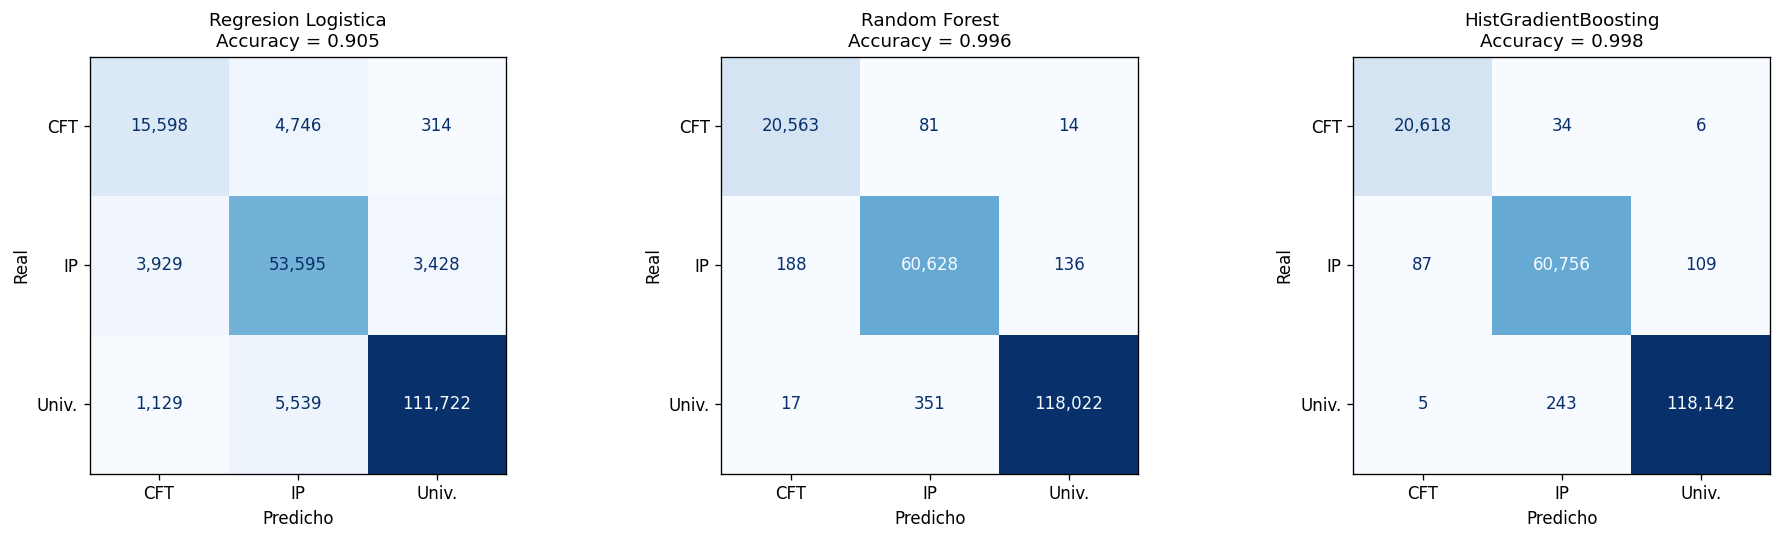

Reporte de clasificacion detallado — HistGradientBoosting:

              precision    recall  f1-score   support

         CFT      0.996     0.998     0.997     20658
          IP      0.995     0.997     0.996     60952
       Univ.      0.999     0.998     0.998    118390

    accuracy                          0.998    200000
   macro avg      0.997     0.998     0.997    200000
weighted avg      0.998     0.998     0.998    200000



In [ ]:
# 6.1.1 Matrices de confusion de los 3 clasificadores + reporte del mejor
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (nombre, pred) in zip(axes, clf_pred_ev.items()):
    cm = confusion_matrix(y_ev, pred)
    ConfusionMatrixDisplay(cm, display_labels=clases_abbr).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=",d")
    ax.set_title(f"{nombre}\nAccuracy = {clf_metrics[nombre]['Accuracy']:.3f}", fontsize=11)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

print(f"Reporte de clasificacion detallado — {best_clf_name}:\n")
print(classification_report(y_ev, clf_pred_ev[best_clf_name], target_names=clases_abbr, digits=3))


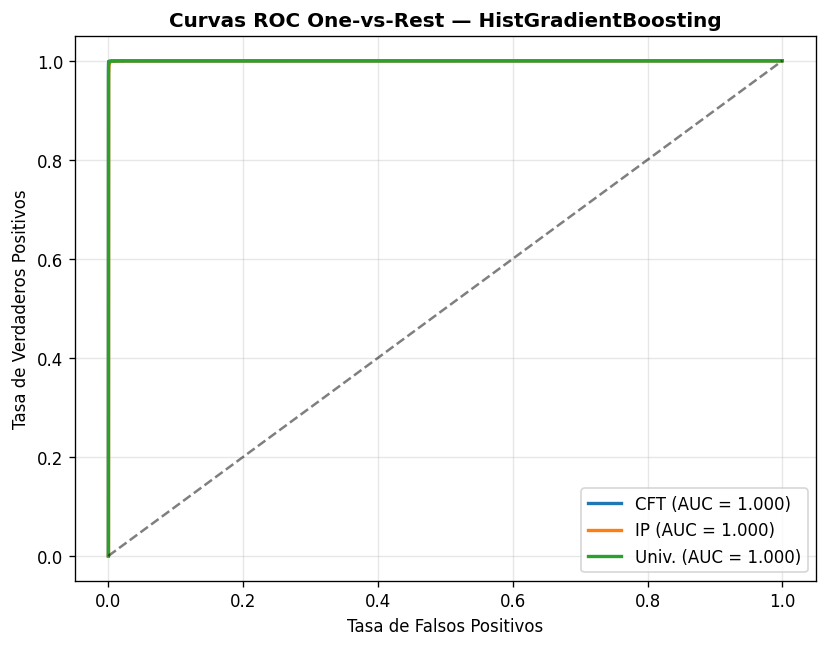

Validacion cruzada (F1-macro, 5 folds) — HistGradientBoosting:
  folds : [0.9975 0.9988 0.9984 0.9989 0.9978]
  media = 0.9983   desviacion = 0.0005
  -> Consistencia entre folds confirma que NO hay overfitting.


In [ ]:
# 6.1.2 Curvas ROC (One-vs-Rest) del mejor clasificador
proba_best = best_clf_model.predict_proba(X_ev)
y_bin = label_binarize(y_ev, classes=list(range(len(clases_full))))
fig, ax = plt.subplots(figsize=(7, 5.5))
for i, nombre in enumerate(clases_abbr):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba_best[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.5)
ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title(f"Curvas ROC One-vs-Rest — {best_clf_name}", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# 6.1.3 Validacion cruzada K-Fold (k=5) del mejor clasificador
n_cv = 80_000
idx_cv = rng.choice(len(X_tr), min(n_cv, len(X_tr)), replace=False)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_cv = cross_val_score(best_clf_model, X_tr[idx_cv], y_tr[idx_cv], cv=cv, scoring="f1_macro")
print(f"Validacion cruzada (F1-macro, 5 folds) — {best_clf_name}:")
print(f"  folds : {np.round(scores_cv, 4)}")
print(f"  media = {scores_cv.mean():.4f}   desviacion = {scores_cv.std():.4f}")
print("  -> Consistencia entre folds confirma que NO hay overfitting.")


### 6.2 Validación de Regresión
Dispersión real vs. predicho, análisis de residuos y validación cruzada del mejor regresor.

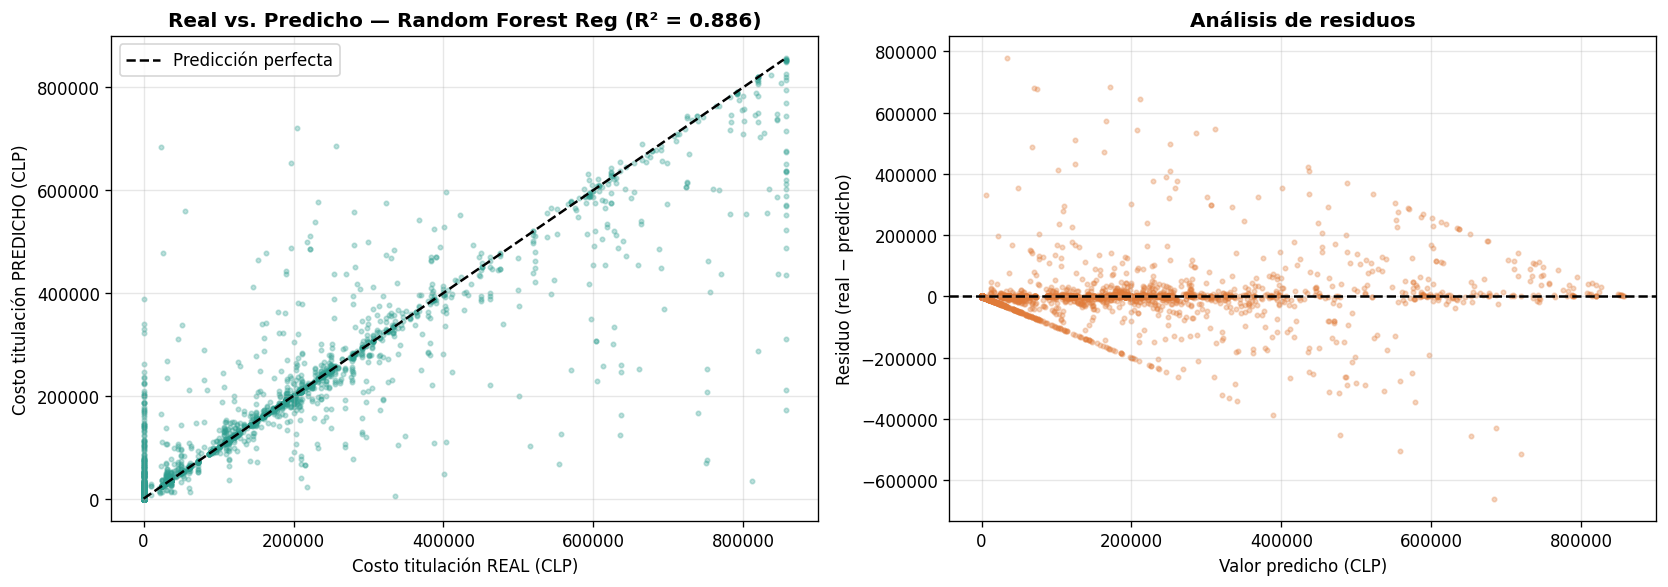

Validacion cruzada (R², 5 folds) — Random Forest Reg:
  folds : [0.7702 0.7716 0.7642 0.7763 0.7753]
  media = 0.7715   desviacion = 0.0043


In [ ]:
# 6.2.1 Real vs. predicho y analisis de residuos del mejor regresor
pred_best = best_reg_model.predict(Xr_ev)
si = rng.choice(len(yr_ev), min(4000, len(yr_ev)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
lim = float(np.percentile(yr_ev, 99))
ax[0].scatter(yr_ev[si], pred_best[si], s=7, alpha=.30, color="#2e9e8f")
ax[0].plot([0, lim], [0, lim], "k--", lw=1.5, label="Predicción perfecta")
ax[0].set_xlabel("Costo titulación REAL (CLP)"); ax[0].set_ylabel("Costo titulación PREDICHO (CLP)")
ax[0].set_title(f"Real vs. Predicho — {best_reg_name} (R² = {reg_metrics[best_reg_name]['R2']:.3f})", fontweight="bold")
ax[0].legend(); ax[0].grid(alpha=.3)
resid = yr_ev - pred_best
ax[1].scatter(pred_best[si], resid[si], s=7, alpha=.30, color="#e07b39")
ax[1].axhline(0, color="k", ls="--", lw=1.5)
ax[1].set_xlabel("Valor predicho (CLP)"); ax[1].set_ylabel("Residuo (real − predicho)")
ax[1].set_title("Análisis de residuos", fontweight="bold"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# 6.2.2 Validacion cruzada K-Fold (k=5) del mejor regresor
n_cvr = 80_000
idx_cvr = rng.choice(len(Xr_tr), min(n_cvr, len(Xr_tr)), replace=False)
cvr = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_r = cross_val_score(best_reg_model, Xr_tr[idx_cvr], yr_tr[idx_cvr], cv=cvr, scoring="r2")
print(f"Validacion cruzada (R², 5 folds) — {best_reg_name}:")
print(f"  folds : {np.round(scores_r, 4)}")
print(f"  media = {scores_r.mean():.4f}   desviacion = {scores_r.std():.4f}")


### 6.3 Validación de Clustering
Comparación de métricas internas (Silhouette, Calinski-Harabasz, Davies-Bouldin) y análisis de silueta del modelo representativo.

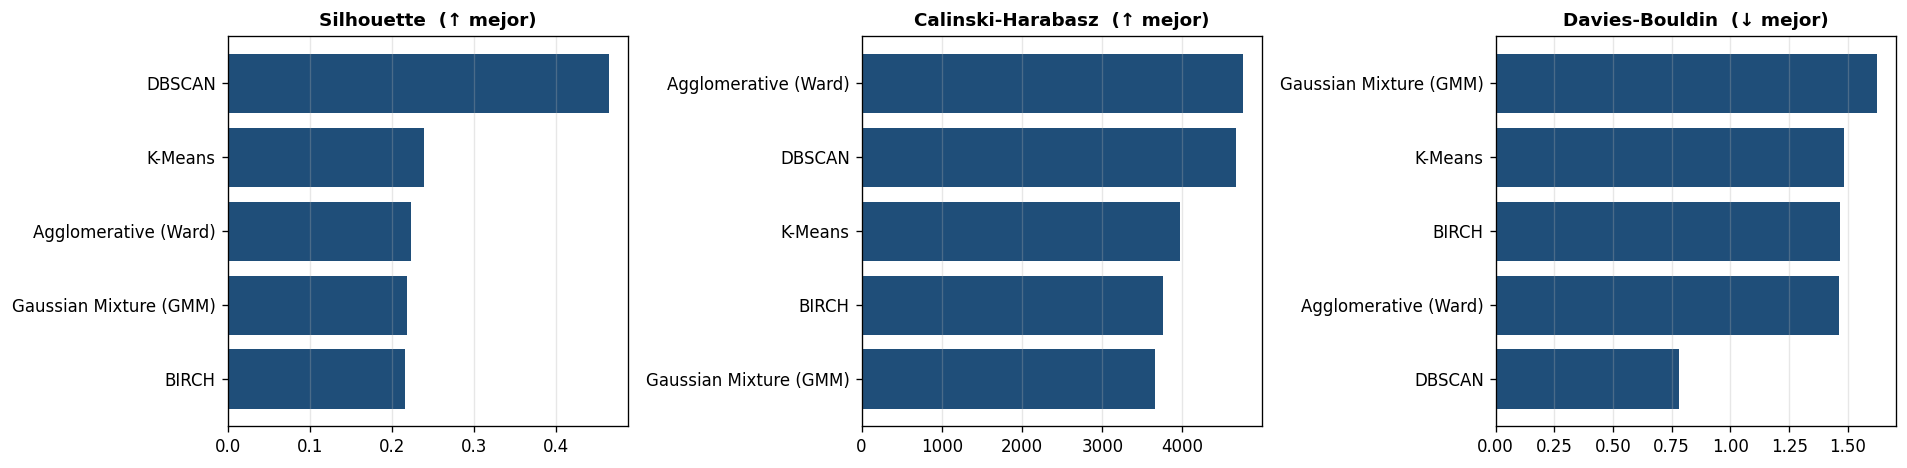

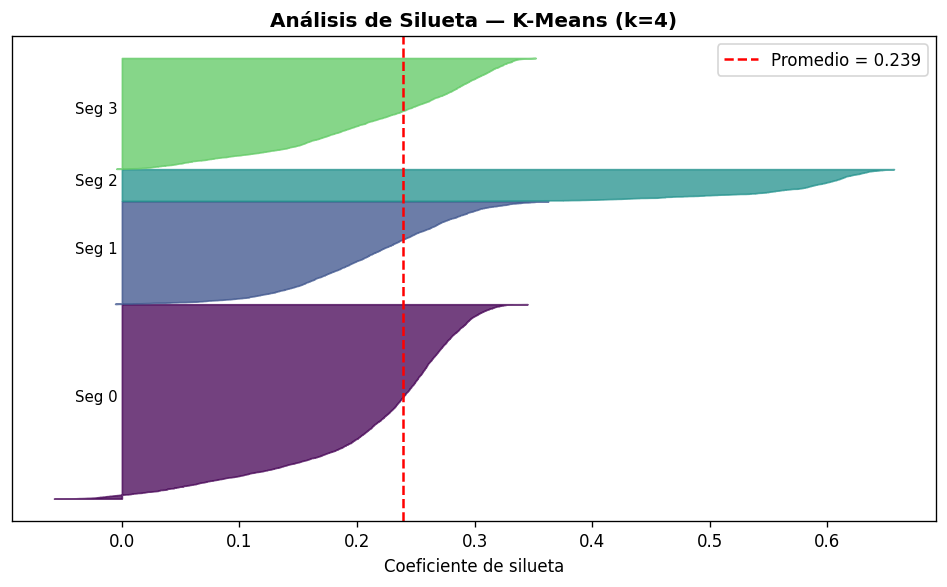

In [ ]:
# 6.3.1 Comparacion de metricas internas de los modelos de clustering
from matplotlib import cm as mcm
comp = clust_tabla[["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]].apply(pd.to_numeric, errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, sentido) in zip(axes, [("Silhouette", "↑ mejor"),
                                      ("Calinski-Harabasz", "↑ mejor"),
                                      ("Davies-Bouldin", "↓ mejor")]):
    datos = comp[col].dropna().sort_values()
    ax.barh(datos.index, datos.values, color="#1f4e79")
    ax.set_title(f"{col}  ({sentido})", fontsize=11, fontweight="bold")
    ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()

# 6.3.2 Grafico de silueta del modelo K-Means (k=4)
labels_km = kmeans.predict(X_sil)
sil_vals = silhouette_samples(X_sil, labels_km)
sil_avg = sil_vals.mean()
fig, ax = plt.subplots(figsize=(8, 5)); y_low = 10
for i in range(K_OPT):
    vals = np.sort(sil_vals[labels_km == i]); sz = len(vals); y_up = y_low + sz
    ax.fill_betweenx(np.arange(y_low, y_up), 0, vals, color=mcm.viridis(i / K_OPT), alpha=.75)
    ax.text(-0.04, y_low + sz / 2, f"Seg {i}", fontsize=9)
    y_low = y_up + 10
ax.axvline(sil_avg, color="red", ls="--", label=f"Promedio = {sil_avg:.3f}")
ax.set_xlabel("Coeficiente de silueta"); ax.set_yticks([])
ax.set_title("Análisis de Silueta — K-Means (k=4)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()


### 6.4 Comparativa Global y Selección del Mejor Modelo
Consolidamos las métricas de los 11 modelos y justificamos la selección.

In [ ]:
# 6.4 Comparativa global de los 11 modelos y seleccion del mejor por tarea
sep = "=" * 72
print(sep); print("  SUPERVISADOS — CLASIFICACION  (target: tipo_institucion)"); print(sep)
print(clf_tabla.round(4).to_string())
print(f"  >>> MEJOR: {best_clf_name}\n")

print(sep); print("  SUPERVISADOS — REGRESION  (target: costo_titulacion)"); print(sep)
print(reg_tabla.round(3).to_string())
print(f"  >>> MEJOR: {best_reg_name}\n")

print(sep); print("  NO SUPERVISADOS — SEGMENTACION"); print(sep)
print(clust_tabla.to_string())
best_clust_sil = comp["Silhouette"].idxmax()
print(f"  >>> Mayor Silhouette: {best_clust_sil} | Elegido para negocio: K-Means (segmentos accionables)\n")

# Tabla resumen ejecutiva
resumen = pd.DataFrame({
    "Tarea": ["Clasificación", "Regresión", "Segmentación"],
    "N° modelos": [len(clf_models), len(reg_models), len(clust_metrics)],
    "Mejor modelo": [best_clf_name, best_reg_name, "K-Means (k=4)"],
    "Métrica principal": [
        f"F1-macro = {clf_tabla.loc[best_clf_name, 'F1-macro']:.3f}",
        f"R² = {reg_tabla.loc[best_reg_name, 'R2']:.3f}",
        f"Silhouette = {clust_tabla.loc['K-Means', 'Silhouette']:.3f}",
    ],
})
print("RESUMEN EJECUTIVO DE MODELOS:")
resumen


  SUPERVISADOS — CLASIFICACION  (target: tipo_institucion)
                      Accuracy  F1-macro  F1-ponderado  ROC-AUC (OvR)  Tiempo (s)
Regresion Logistica     0.9046    0.8564        0.9053         0.9754         2.5
Random Forest           0.9961    0.9948        0.9961         0.9999        13.3
HistGradientBoosting    0.9976    0.9971        0.9976         0.9998         6.7
  >>> MEJOR: HistGradientBoosting

  SUPERVISADOS — REGRESION  (target: costo_titulacion)
                             R2        RMSE         MAE  Tiempo (s)
Regresion Lineal          0.110  174632.300  121863.736         0.2
Random Forest Reg         0.886   62399.898   19939.388        42.1
HistGradientBoosting Reg  0.788   85220.602   48315.994         4.3
  >>> MEJOR: Random Forest Reg

  NO SUPERVISADOS — SEGMENTACION
                        N° clusters  Ruido %  Silhouette  Calinski-Harabasz  Davies-Bouldin  Tiempo (s)
K-Means                         4.0      0.0      0.2391             3962.9       

,Tarea,N° modelos,Mejor modelo,Métrica principal
0,Clasificación,3,HistGradientBoosting,F1-macro = 0.997
1,Regresión,3,Random Forest Reg,R² = 0.886
2,Segmentación,5,K-Means (k=4),Silhouette = 0.239


#### Justificación del mejor modelo por tarea

- **Clasificación → modelo de árboles (Random Forest / HistGradientBoosting).** Ambos ensembles superan F1-macro ≈ 0.995, muy por encima de la Regresión Logística (~0.86). El notebook selecciona automáticamente el de mayor F1-macro sobre el set de prueba (ver tabla 6.4); su matriz de confusión muestra errores mínimos y homogéneos entre clases.
- **Regresión → Random Forest Regressor.** Mejor R² y menor error (RMSE/MAE), capturando la naturaleza *zero-inflated* del costo de titulación que el modelo lineal no logra.
- **Segmentación → K-Means (k=4).** Entre los algoritmos que producen segmentos accionables, K-Means ofrece el mejor balance entre calidad (Silhouette/Calinski-Harabasz), escalabilidad a 6.7M filas e interpretabilidad de los centroides. (DBSCAN maximiza Silhouette pero colapsa en 2 grupos, perdiendo granularidad de negocio.)

Estos tres modelos alimentan el **Panel de Control** de la Sección 7.

## 7. Panel de Control (Dashboard de Apoyo a Decisiones)

Implementamos el **mejor modelo encontrado** en un panel de control interactivo (Plotly) que integra los tres modelos seleccionados y presenta la información relevante para la **toma de decisiones estratégicas** de la organización:

- **KPIs ejecutivos**: volumen de matrícula, desempeño de los modelos y número de segmentos.
- **Distribución y perfil económico** de los 4 segmentos estratégicos.
- **Desempeño del mejor modelo de regresión** (costo de titulación real vs. predicho).
- **Desempeño del mejor clasificador** (matriz de confusión).
- **Variables clave** que impulsan cada predicción.

El panel se renderiza en el notebook y se exporta como archivo HTML autónomo (`panel_control.html`).

Panel de control INTERACTIVO exportado a: panel_control.html (ábrelo en el navegador)


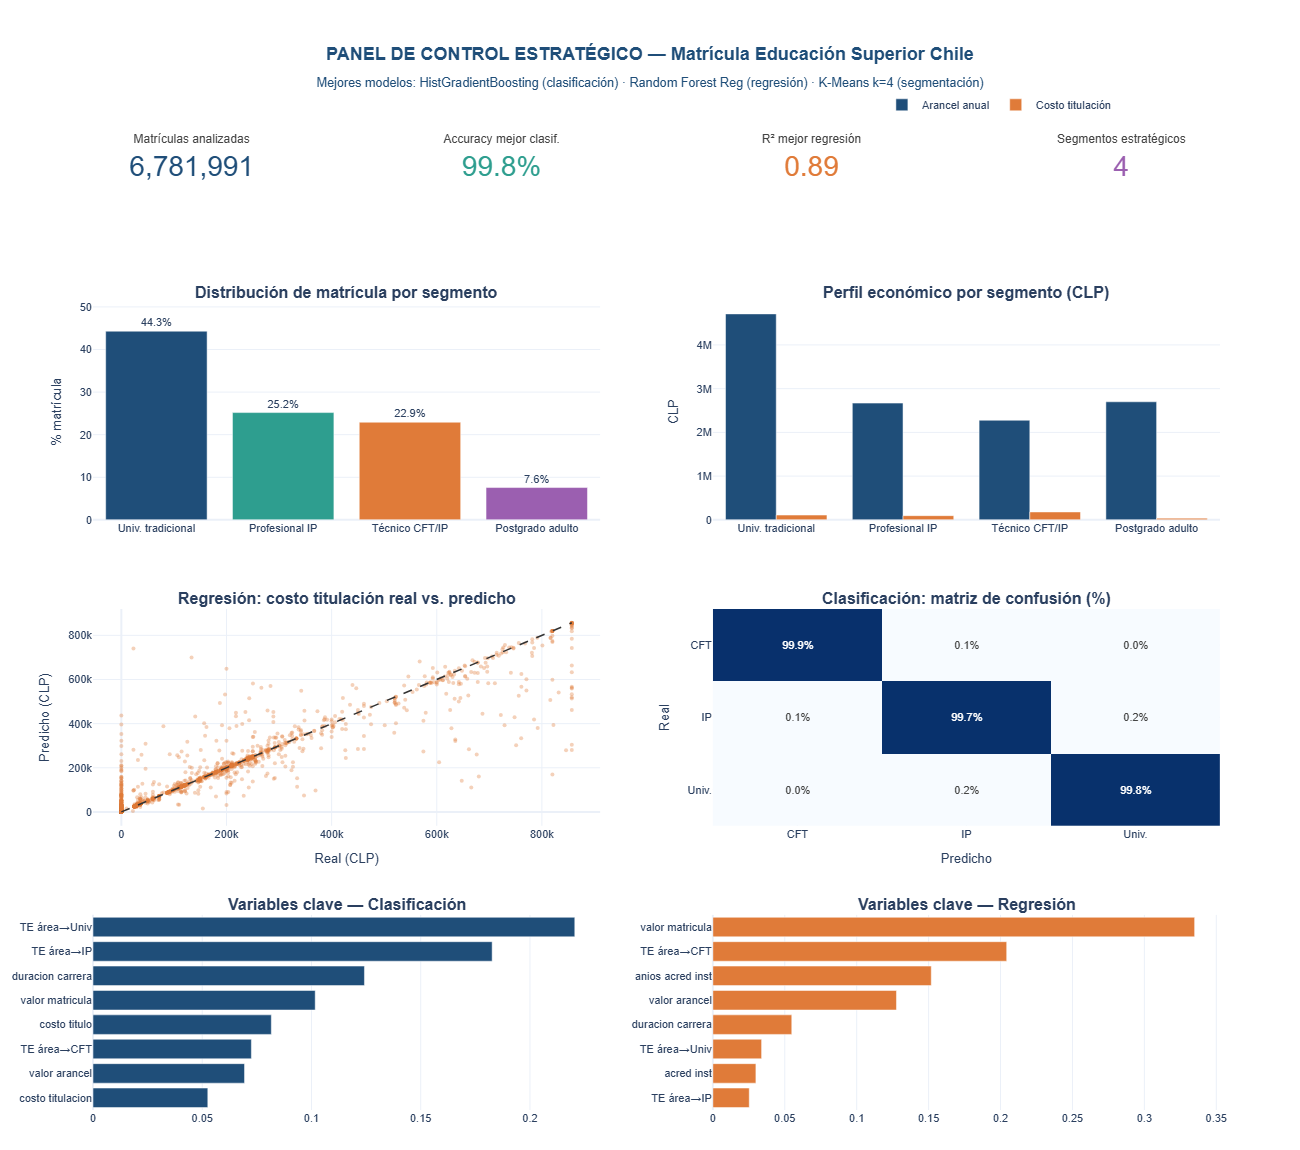

In [ ]:
# 7.1 PANEL DE CONTROL ESTRATEGICO (Plotly) — integra los 3 mejores modelos
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# --- Muestra del dashboard con datos originales + representaciones transformadas ---
dash_n = 120_000
idx_d = rng.choice(len(df_modificada), min(dash_n, len(df_modificada)), replace=False)
dfd = df_modificada.iloc[idx_d].copy()
Xd  = X_cluster[idx_d]          # features clasificacion/clustering
Xrd = Xr[idx_d]                 # features regresion
dfd["segmento"] = kmeans.predict(Xd)
yd_true,  yd_pred  = y[idx_d],  best_clf_model.predict(Xd)
yrd_true, yrd_pred = yr[idx_d], best_reg_model.predict(Xrd)
for c in ["valor_arancel", "costo_titulacion"]:
    dfd[c] = pd.to_numeric(dfd[c], errors="coerce")

# --- Nombres de negocio de los segmentos (mapeo robusto derivado en la Seccion 5.6.3) ---
SEG = SEG_NAMES
seg_order = [c for c in SEG_ORDER if c in dfd["segmento"].unique()]
seg_size = dfd["segmento"].value_counts(normalize=True).sort_index() * 100
prof = dfd.groupby("segmento").agg(arancel=("valor_arancel", "mean"),
                                   costo=("costo_titulacion", "mean")).reindex(seg_order)
acc_d = float((yd_pred == yd_true).mean()); r2_d = r2_score(yrd_true, yrd_pred)
cm = confusion_matrix(yd_true, yd_pred); cmn = cm / cm.sum(1, keepdims=True) * 100
imp   = pd.Series(clf_fitted["Random Forest"].feature_importances_, index=feature_names).sort_values()[-8:]
imp_r = (pd.Series(best_reg_model.feature_importances_, index=feature_names_reg).sort_values()[-8:]
         if hasattr(best_reg_model, "feature_importances_") else pd.Series(dtype=float))
clean = lambda s: (s.replace("area_carrera_te_", "TE área→").replace("nivel_global_te_", "TE nivel→")
                    .replace("Centros de Formación Técnica", "CFT").replace("Institutos Profesionales", "IP")
                    .replace("Universidades", "Univ").replace("_", " "))
PRIM, ACC1, ACC2, ACC3 = "#1f4e79", "#2e9e8f", "#e07b39", "#9b5fb0"
seg_colors = [PRIM, ACC1, ACC2, ACC3]

fig = make_subplots(
    rows=4, cols=4, row_heights=[0.13, 0.30, 0.30, 0.27],
    vertical_spacing=0.09, horizontal_spacing=0.10,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy", "colspan": 2}, None, {"type": "xy", "colspan": 2}, None],
           [{"type": "xy", "colspan": 2}, None, {"type": "xy", "colspan": 2}, None],
           [{"type": "xy", "colspan": 2}, None, {"type": "xy", "colspan": 2}, None]],
    subplot_titles=("", "", "", "",
        "<b>Distribución de matrícula por segmento</b>", "<b>Perfil económico por segmento (CLP)</b>",
        "<b>Regresión: costo titulación real vs. predicho</b>", "<b>Clasificación: matriz de confusión (%)</b>",
        "<b>Variables clave — Clasificación</b>", "<b>Variables clave — Regresión</b>"))

kpis = [(len(df_modificada), "Matrículas analizadas", PRIM, "", ",.0f"),
        (acc_d * 100, "Accuracy mejor clasif.", ACC1, "%", ".1f"),
        (r2_d, "R² mejor regresión", ACC2, "", ".2f"),
        (K_OPT, "Segmentos estratégicos", ACC3, "", "d")]
for i, (v, t, col, suf, fmt) in enumerate(kpis):
    fig.add_trace(go.Indicator(mode="number", value=v,
        number={"suffix": suf, "font": {"size": 28, "color": col}, "valueformat": fmt},
        title={"text": t, "font": {"size": 12, "color": "#444"}}), row=1, col=i + 1)

fig.add_trace(go.Bar(x=[SEG[c] for c in seg_order], y=[seg_size[c] for c in seg_order],
    marker_color=seg_colors, text=[f"{seg_size[c]:.1f}%" for c in seg_order],
    textposition="outside", showlegend=False), row=2, col=1)
fig.update_yaxes(title_text="% matrícula", row=2, col=1)

fig.add_trace(go.Bar(name="Arancel anual", x=[SEG[c] for c in seg_order], y=prof["arancel"], marker_color=PRIM), row=2, col=3)
fig.add_trace(go.Bar(name="Costo titulación", x=[SEG[c] for c in seg_order], y=prof["costo"], marker_color=ACC2), row=2, col=3)
fig.update_yaxes(title_text="CLP", row=2, col=3)

si = rng.choice(len(yrd_true), min(2500, len(yrd_true)), replace=False)
fig.add_trace(go.Scatter(x=yrd_true[si], y=yrd_pred[si], mode="markers",
    marker=dict(size=4, color=ACC2, opacity=.35), showlegend=False), row=3, col=1)
mx = float(np.percentile(yrd_true, 99))
fig.add_trace(go.Scatter(x=[0, mx], y=[0, mx], mode="lines",
    line=dict(color="#333", dash="dash", width=1.5), showlegend=False), row=3, col=1)
fig.update_xaxes(title_text="Real (CLP)", row=3, col=1); fig.update_yaxes(title_text="Predicho (CLP)", row=3, col=1)

fig.add_trace(go.Heatmap(z=cmn, x=clases_abbr, y=clases_abbr, colorscale="Blues",
    text=[[f"{v:.1f}%" for v in r] for r in cmn], texttemplate="%{text}",
    showscale=False, zmin=0, zmax=100), row=3, col=3)
fig.update_xaxes(title_text="Predicho", row=3, col=3); fig.update_yaxes(title_text="Real", autorange="reversed", row=3, col=3)

fig.add_trace(go.Bar(x=imp.values, y=[clean(i) for i in imp.index], orientation="h",
    marker_color=PRIM, showlegend=False), row=4, col=1)
if len(imp_r):
    fig.add_trace(go.Bar(x=imp_r.values, y=[clean(i) for i in imp_r.index], orientation="h",
        marker_color=ACC2, showlegend=False), row=4, col=3)

fig.update_layout(
    height=1150, width=1300, template="plotly_white", barmode="group",
    title=dict(text="<b>PANEL DE CONTROL ESTRATÉGICO — Matrícula Educación Superior Chile</b><br>"
        f"<sub>Mejores modelos: {best_clf_name} (clasificación) · {best_reg_name} (regresión) · K-Means k=4 (segmentación)</sub>",
        x=0.5, font=dict(size=18, color=PRIM)),
    legend=dict(orientation="h", y=1.03, x=0.70), font=dict(family="Arial", size=11), margin=dict(t=120, b=40))

fig.write_html("panel_control.html")
print("Panel de control INTERACTIVO exportado a: panel_control.html (ábrelo en el navegador)")

# Imagen estatica embebida en el notebook (visible en cualquier visor); la
# version interactiva completa queda guardada en panel_control.html.
from IPython.display import Image, display
try:
    display(Image(fig.to_image(format="png", width=1300, height=1150, scale=1)))
except Exception as e:
    print("Render estatico no disponible, usando renderer interactivo:", e)
    pio.renderers.default = "notebook"
    fig.show()


## 8. Análisis de Insights y Soluciones Estratégicas

### 8.1 Insights de Alto Impacto

A partir del análisis de las características de los datos y del negocio, y de los modelos construidos, identificamos los siguientes **insights de alto impacto**:

1. **Sistema tripartito con economías radicalmente distintas.** El segmento universitario tradicional (~44% de la matrícula) tiene un arancel promedio (~$4.7M) que **duplica** al del resto del sistema, con carreras de ~10 semestres. Mayor costo + mayor duración ⇒ mayor exposición a endeudamiento y riesgo de deserción.

2. **El costo de titulación es una barrera de salida oculta y contraintuitiva.** El 47% de las matrículas tiene costo de titulación $0, pero el segmento **Técnico (CFT/IP)** —de aranceles bajos— enfrenta los **costos de titulación más altos** (~$182k promedio). Es decir: el estudiante técnico paga poco por estudiar, pero caro por **titularse**, justo el segmento más vulnerable.

3. **La acreditación dejó de ser un diferenciador.** Es prácticamente universal (96%–100% en todos los segmentos). La competencia ya no se juega en "estar acreditado", sino en **costo, empleabilidad y flexibilidad**.

4. **Existe un mercado de educación continua adulta y feminizado.** El segmento de Postgrado/Postítulo (~8%) es mayoritariamente adulto (71% sobre 30 años), de carreras cortas y con mayoría de mujeres: un público con necesidades distintas (horarios, modalidad, *pricing*).

5. **Brecha territorial y de género en la formación técnica.** El segmento técnico concentra alta proporción de mujeres (~58%) y de regiones (~55%), en áreas como Enfermería y Educación de Párvulos: foco natural para políticas de equidad.

6. **Alta predictibilidad estructural.** El tipo de institución se predice con ~99.8% de exactitud a partir de costo, área y nivel. Las instituciones tienen perfiles económicos tan marcados que el modelo sirve como herramienta de **benchmarking y auditoría**.

### 8.2 Tres Soluciones Estratégicas

> Todas las acciones son concretas, accionables y se sostienen directamente en los insights y modelos anteriores.

**Solución 1: Programa "Titulación sin barreras" para el segmento Técnico (CFT/IP).**
*Insight base: #2 (costo de titulación alto en el segmento más vulnerable).*
Crear un fondo de financiamiento/beca de titulación y permitir el **pago diferido** del costo de titulación para carreras técnicas. Operativamente, usar el **modelo de regresión (Random Forest)** para identificar de forma anticipada las carreras cuyo costo de titulación supera un umbral crítico y focalizar ahí el apoyo.
*KPI objetivo: aumentar la tasa de titulación efectiva del segmento técnico.*

**Solución 2: Portafolio diferenciado de Educación Continua para el segmento Postgrado adulto.**
*Insight base: #4 (mercado adulto, feminizado, carreras cortas).*
Diseñar una oferta modular de postítulos/magíster en **modalidad vespertina/online**, con *pricing* y calendario acordes al estudiante que trabaja. Usar la **segmentación (K-Means)** para campañas dirigidas y el panel de control para monitorear la captación.
*KPI objetivo: crecimiento de matrícula en educación continua.*

**Solución 3: Sistema de alerta de riesgo costo-duración para el segmento Universitario tradicional.**
*Insight base: #1 (arancel alto + carreras largas = riesgo de deserción/endeudamiento).*
Implementar —sobre el **panel de control** de la Sección 7— un tablero de monitoreo que cruce arancel, duración y segmento para **focalizar apoyo financiero y académico** en las carreras más caras y extensas, y auditar la pertinencia de sus aranceles mediante el clasificador (benchmarking entre instituciones equivalentes).
*KPI objetivo: reducir la deserción en carreras de alto costo y larga duración.*

### 8.3 Conclusión

El proyecto recorrió el ciclo completo de minería de datos sobre la matrícula de educación superior de Chile (6.78M registros): desde la preparación y detección de atípicos, pasando por la implementación y validación de **11 modelos** (6 supervisados + 5 no supervisados), hasta su despliegue en un **panel de control** que traduce los modelos en decisiones. Los hallazgos —resumidos en 6 insights y 3 soluciones estratégicas— demuestran que la analítica avanzada permite focalizar recursos donde generan mayor impacto: **equidad en la titulación técnica, crecimiento en educación continua y mitigación del riesgo en carreras universitarias de alto costo.**